## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,StandardScaler,FunctionTransformer
import mlflow
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler,SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from mlflow.tracking import MlflowClient
import optuna

/Users/akhilendra.singh/Documents/Fraud-Detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('creditcard.csv')

## Some info about the data

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.shape

(284807, 31)

In [9]:
df.duplicated().sum()

1081

## Exploratory Data Analysis

### Data imbalance

In [10]:
data = df['Class'].value_counts(normalize=True)*100
print(data)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


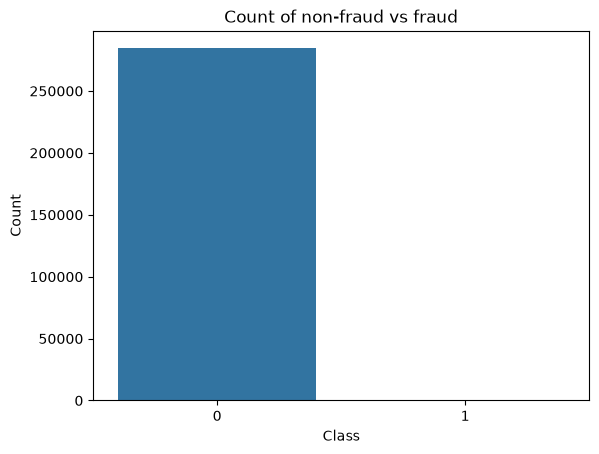

In [11]:
sns.countplot(data = df,x = 'Class')
plt.title("Count of non-fraud vs fraud")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Amount column analysis

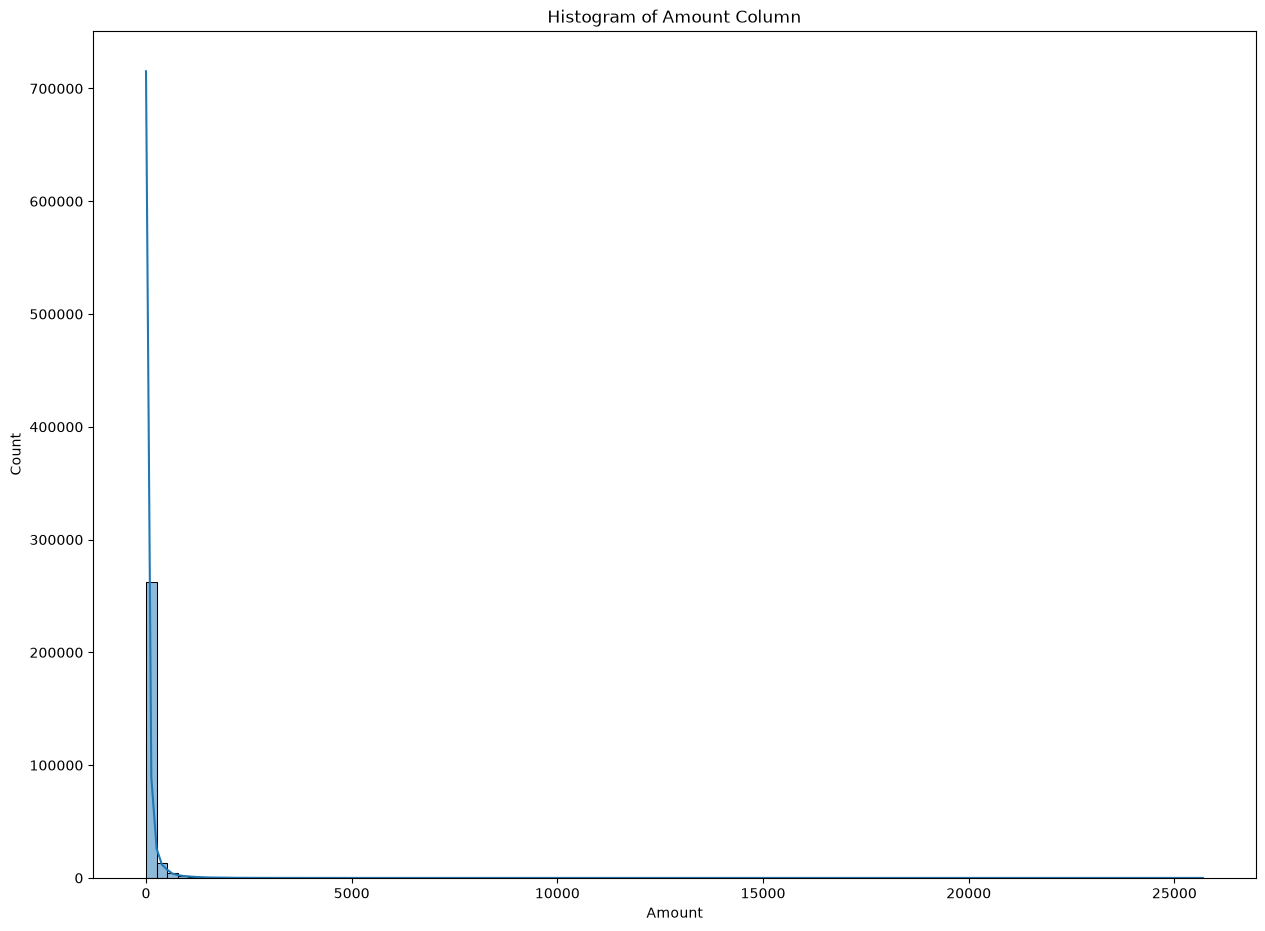

In [12]:
plt.figure(figsize=(15,11))
sns.histplot(data = df,x = 'Amount',bins=100,kde=True)
plt.title("Histogram of Amount Column")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

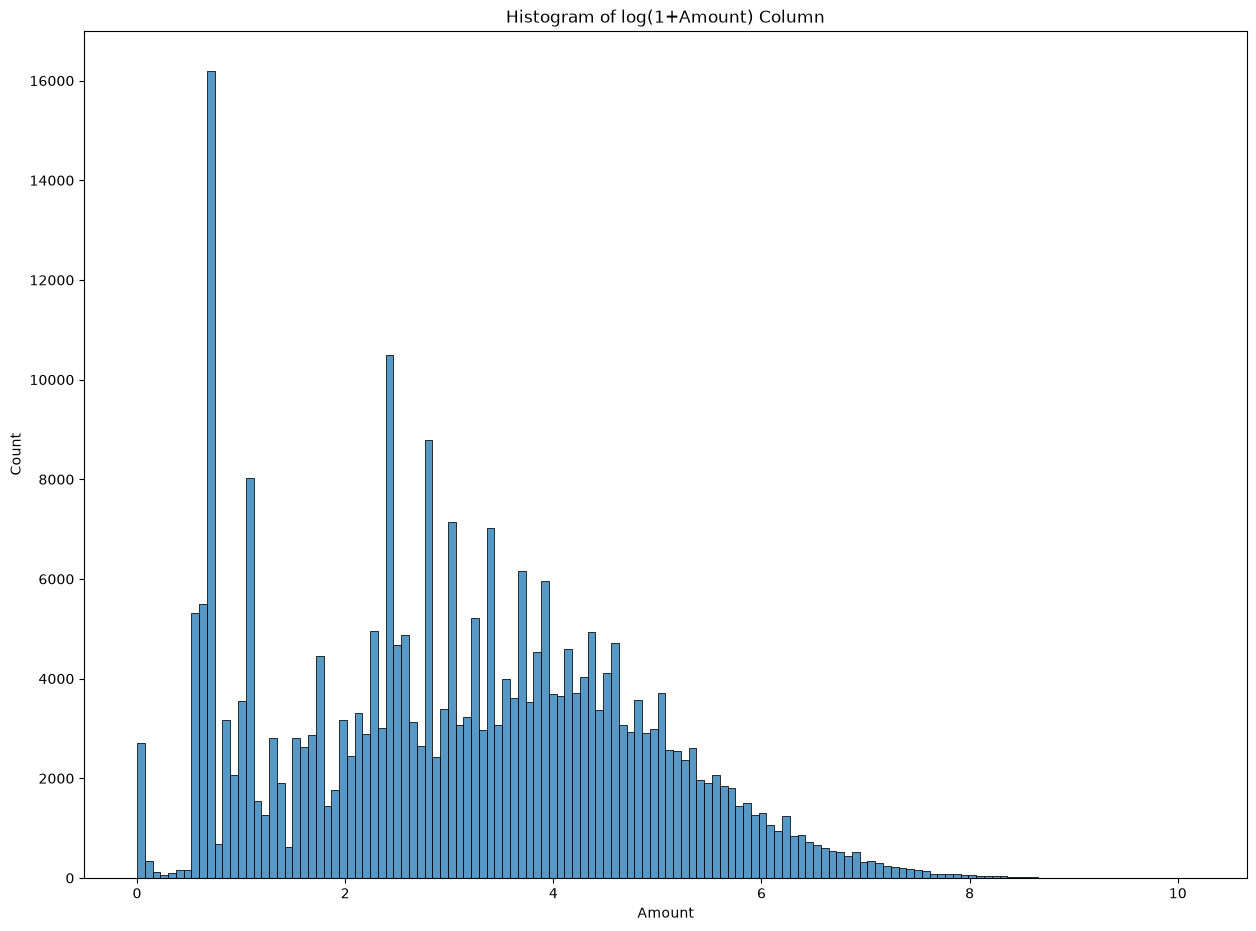

In [13]:
col = np.log1p(df['Amount'])#log(1+amount)
plt.figure(figsize=(15,11))
sns.histplot(x = col)
plt.title("Histogram of log(1+Amount) Column")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()


<Axes: xlabel='Class', ylabel='Amount'>

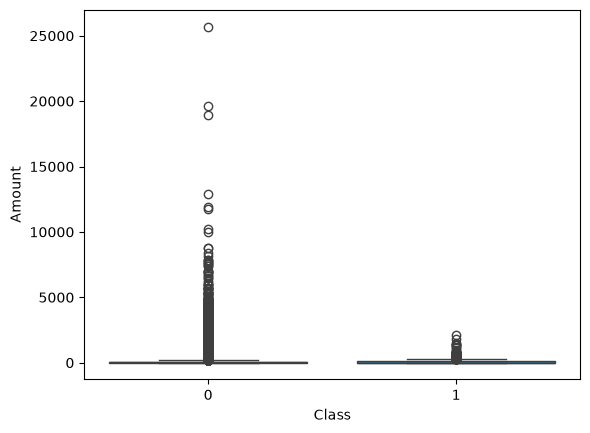

In [14]:
sns.boxplot(data=df,x = 'Class',y = 'Amount')

<Axes: xlabel='Class', ylabel='Amount'>

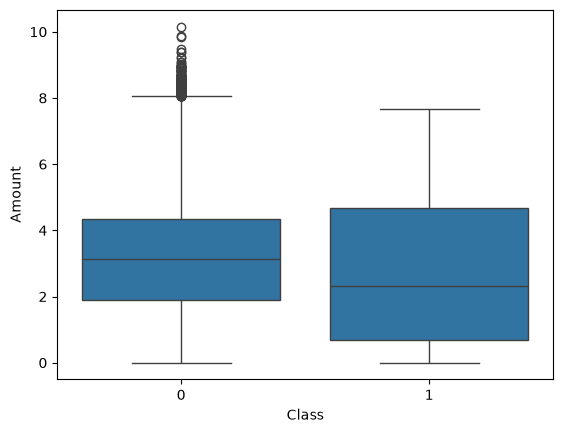

In [15]:
sns.boxplot(data = df,x = 'Class',y = col)#Log is more interpretable

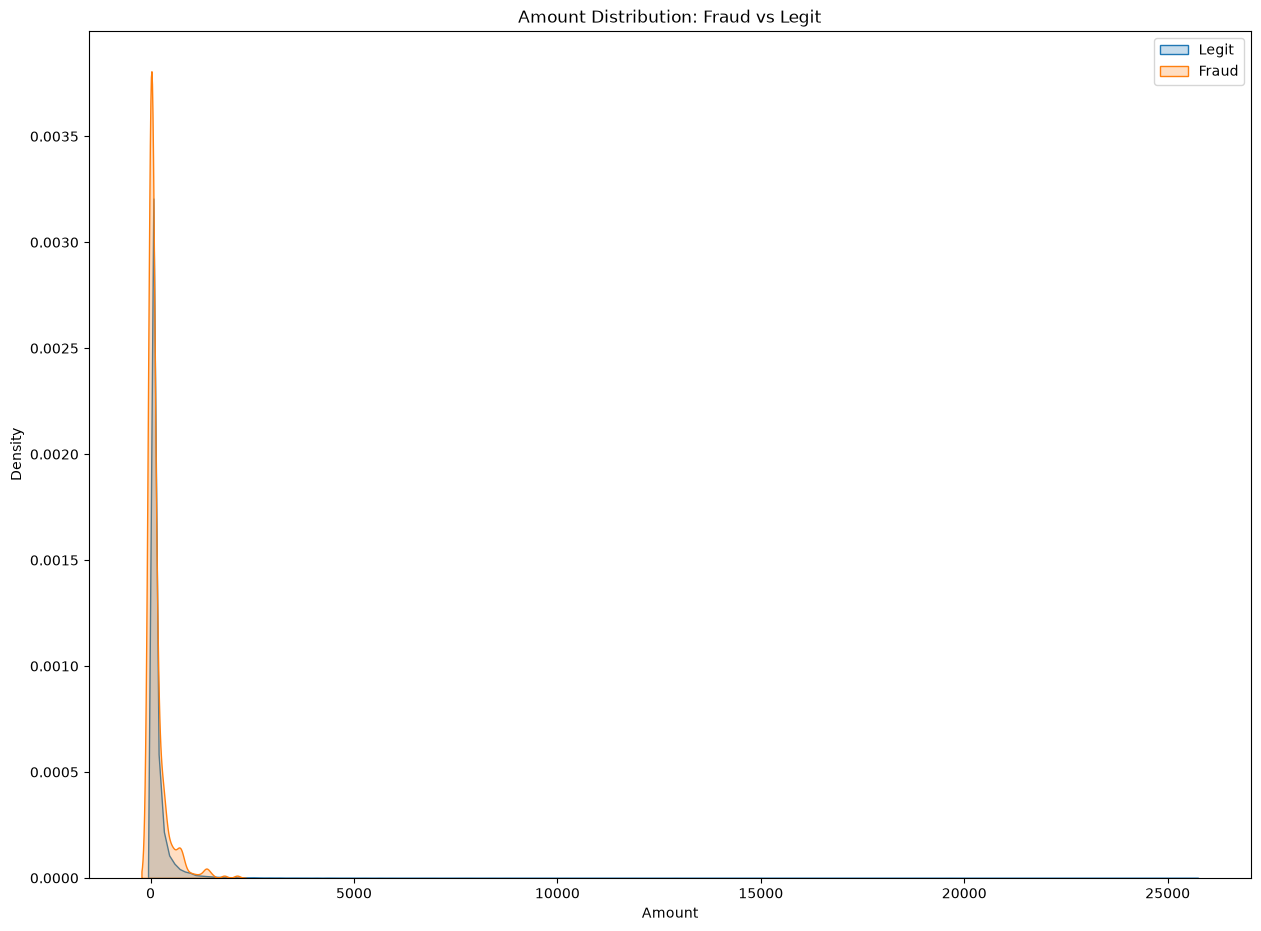

In [16]:
nonfraud = df[df['Class']==0]
fraud = df[df['Class']==1]
plt.figure(figsize=(15, 11))
sns.kdeplot((nonfraud['Amount']), label='Legit', fill=True, common_norm=False)
sns.kdeplot((fraud['Amount']), label='Fraud', fill=True, common_norm=False)
plt.title('Amount Distribution: Fraud vs Legit')
plt.xlabel('Amount')
plt.legend()
plt.show()


### Time column analysis

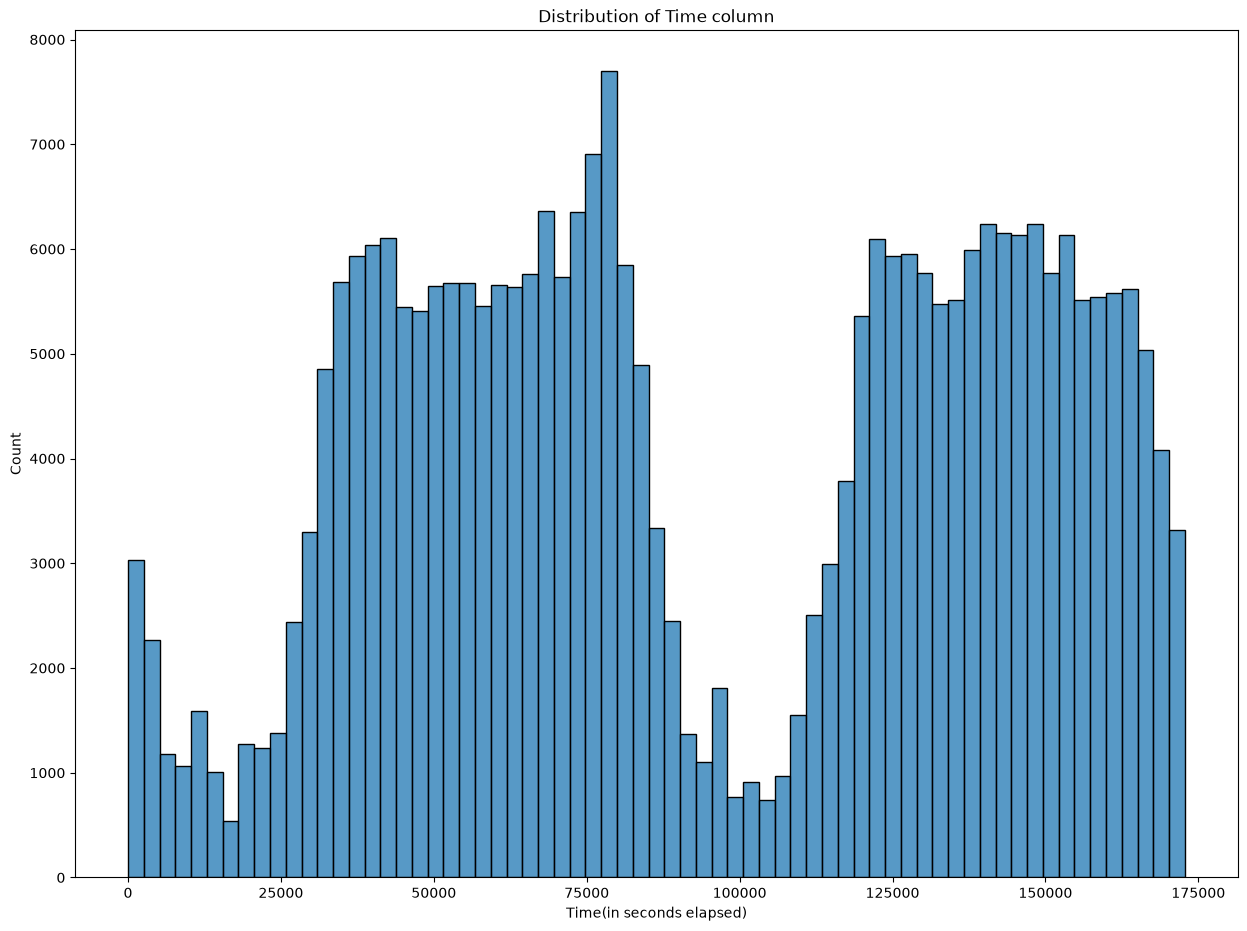

In [17]:
plt.figure(figsize=(15, 11))
sns.histplot(data=df,x = 'Time')
plt.title('Distribution of Time column')
plt.xlabel('Time(in seconds elapsed)')
plt.ylabel('Count')
plt.show()


### V1 to V28 analysis

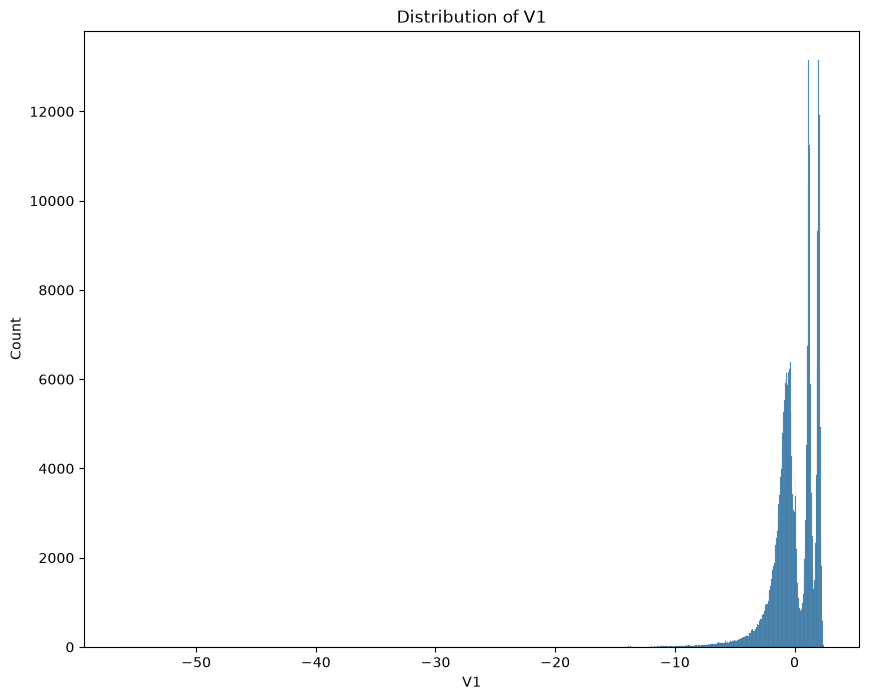

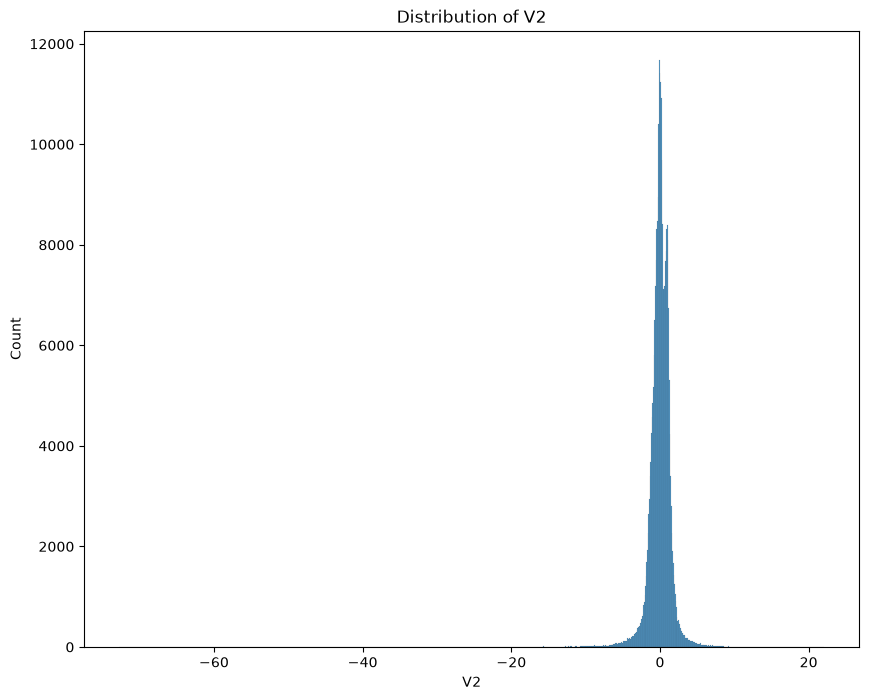

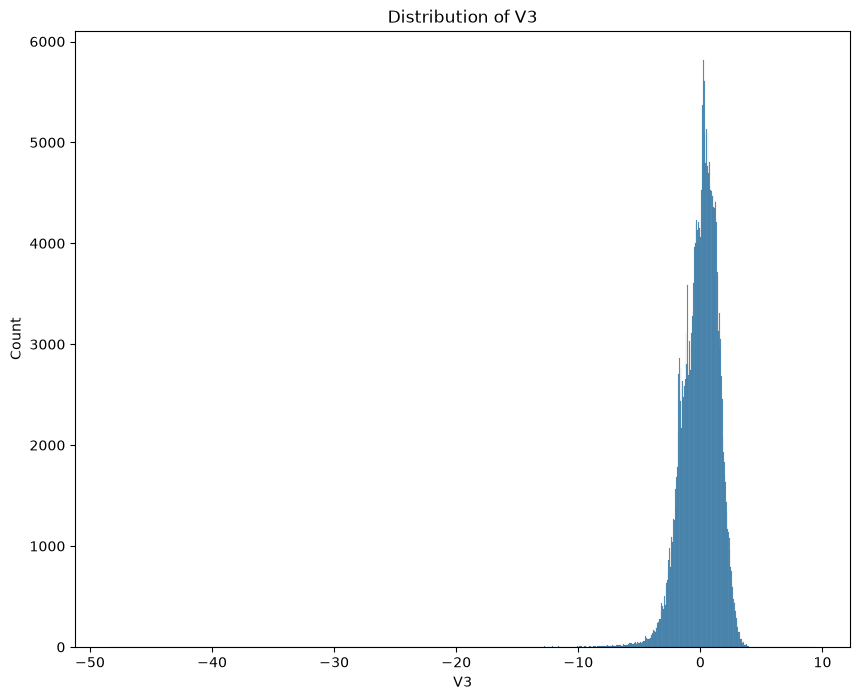

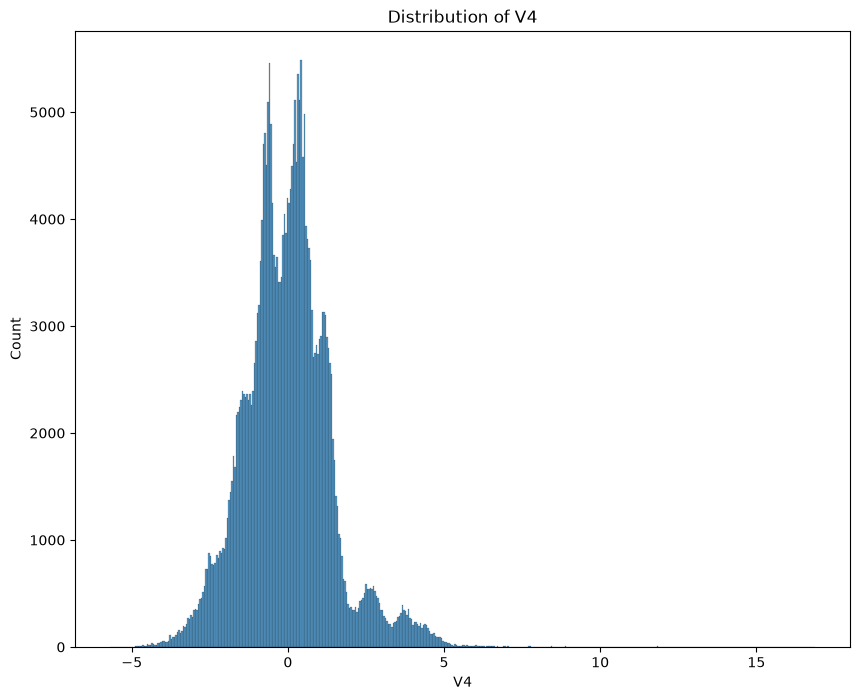

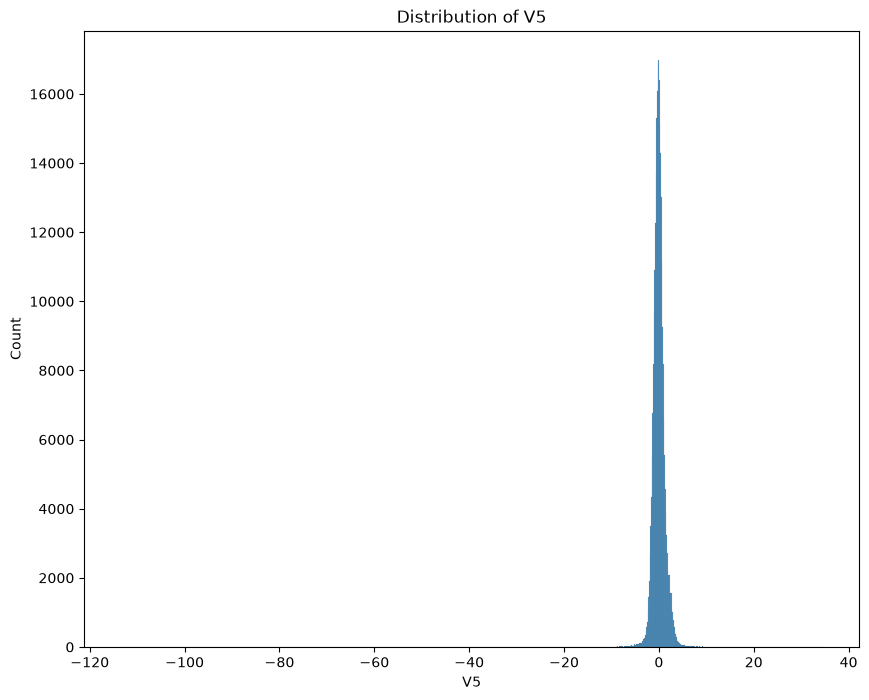

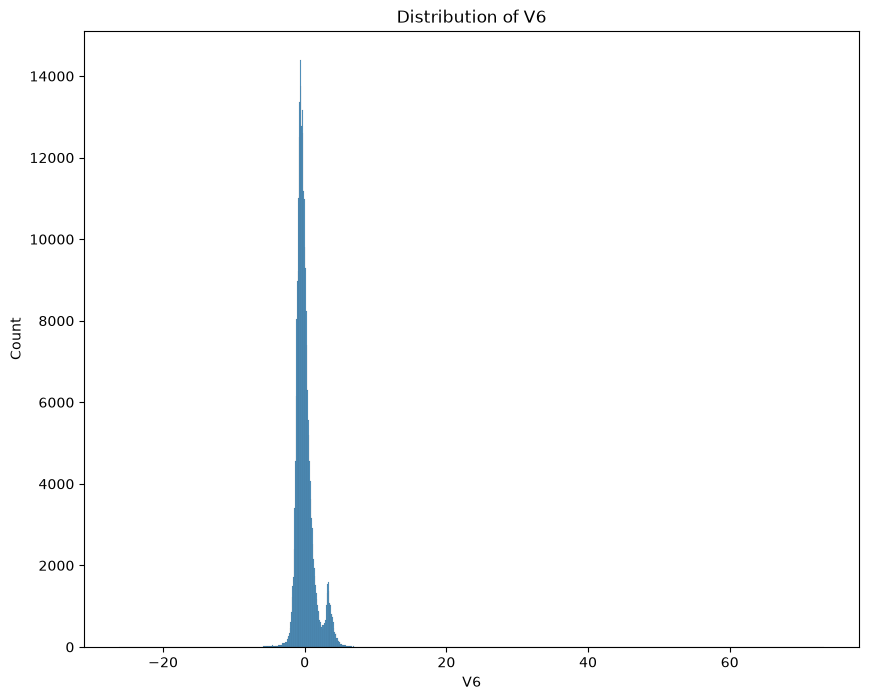

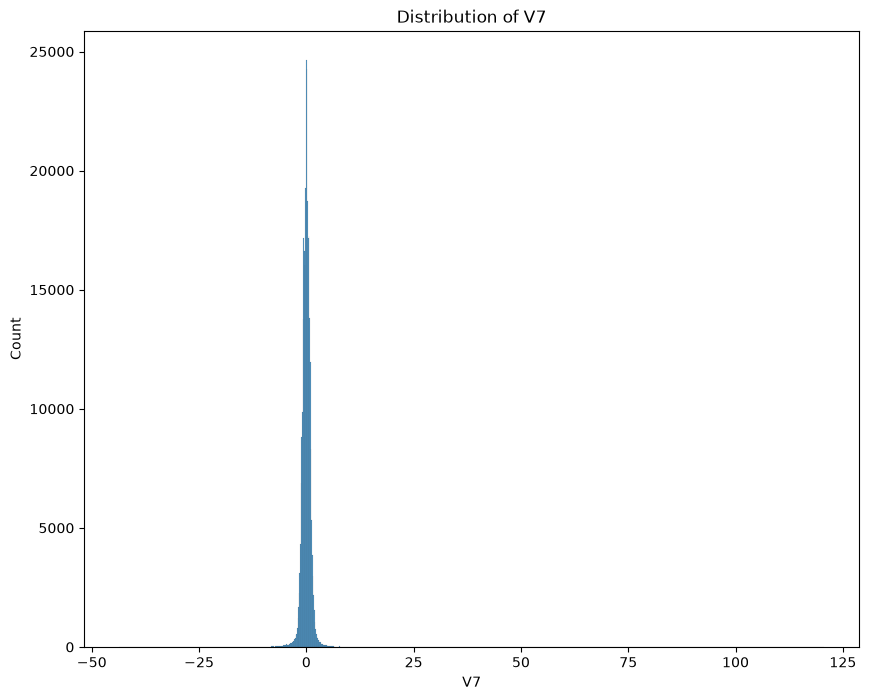

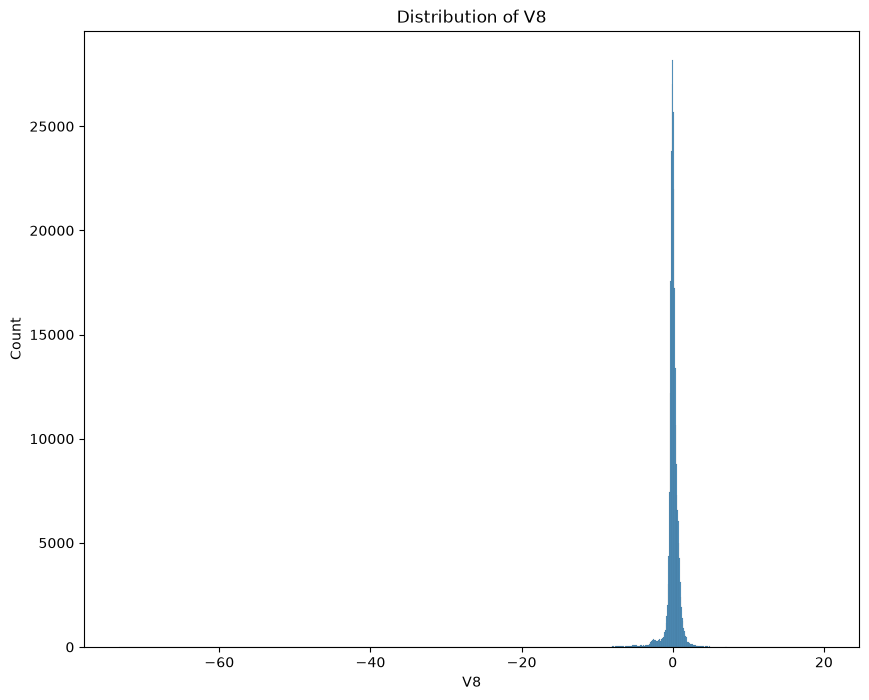

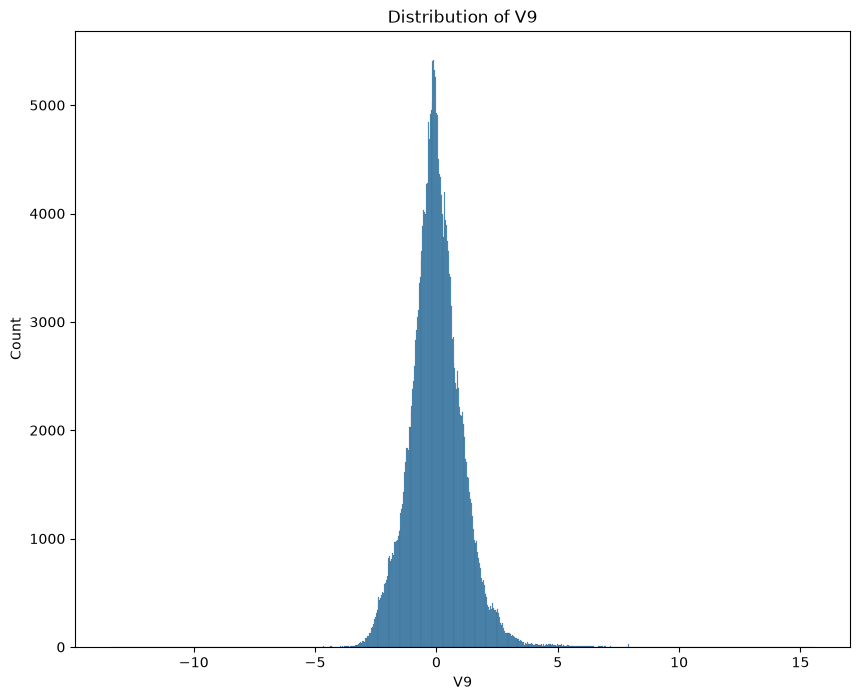

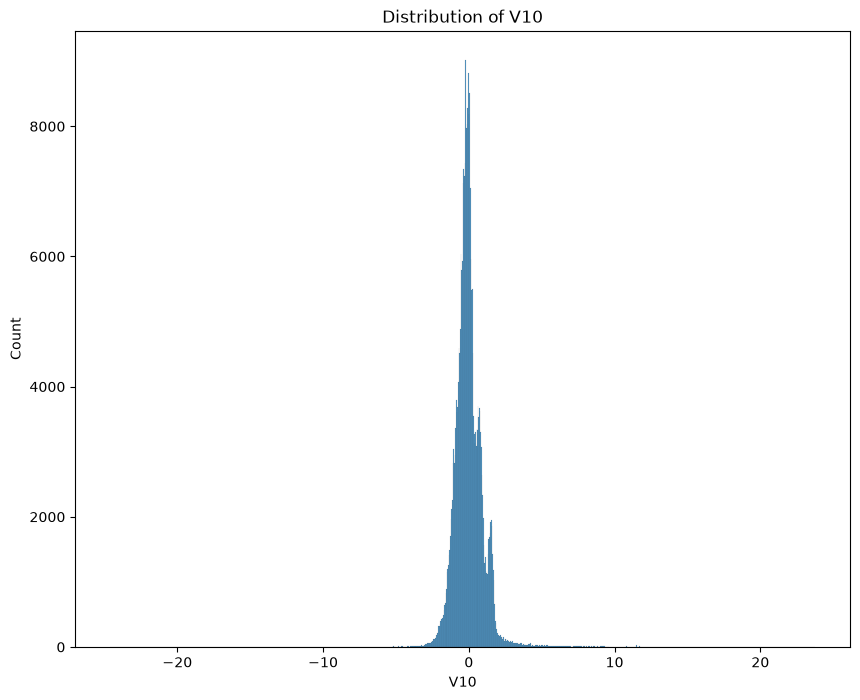

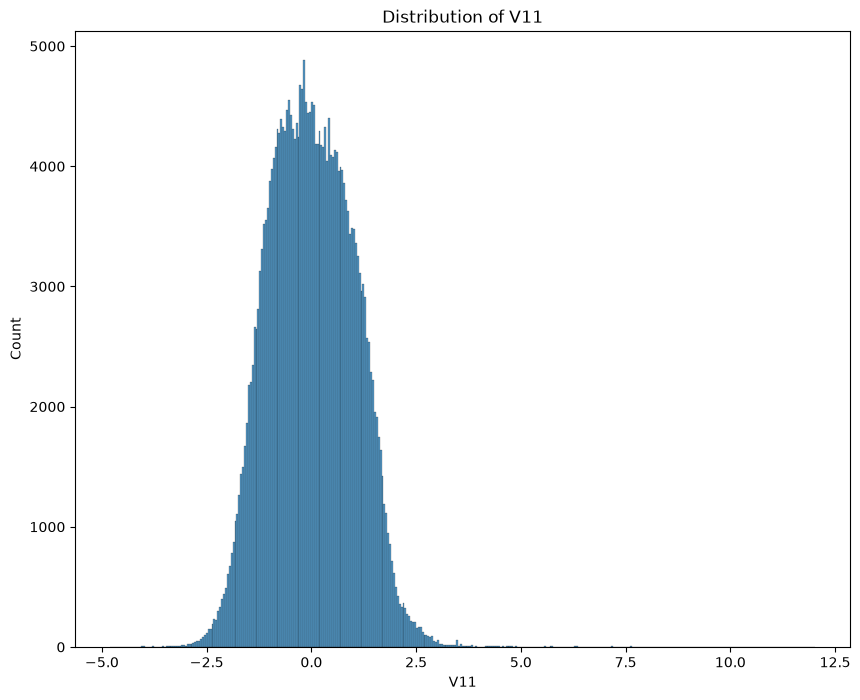

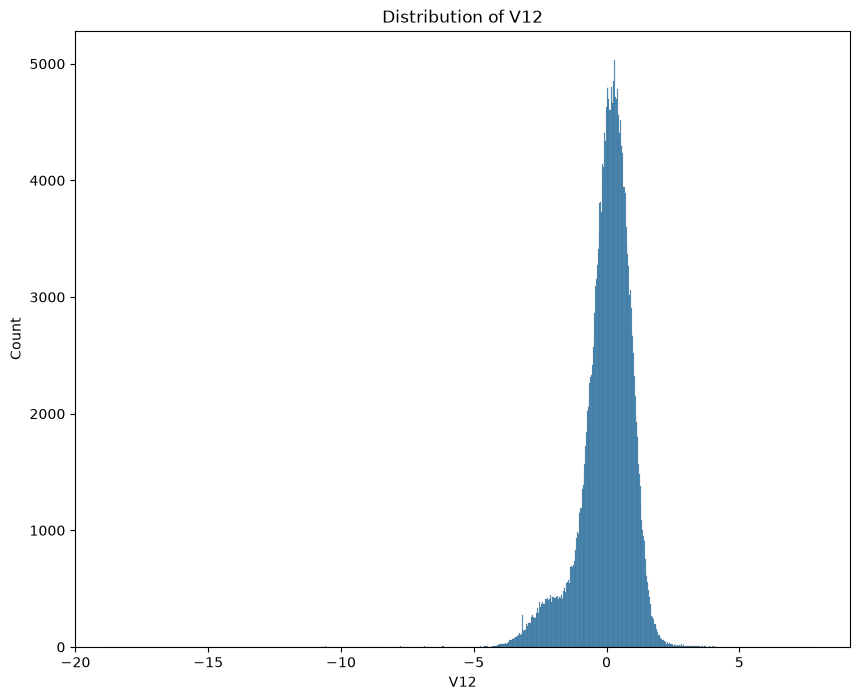

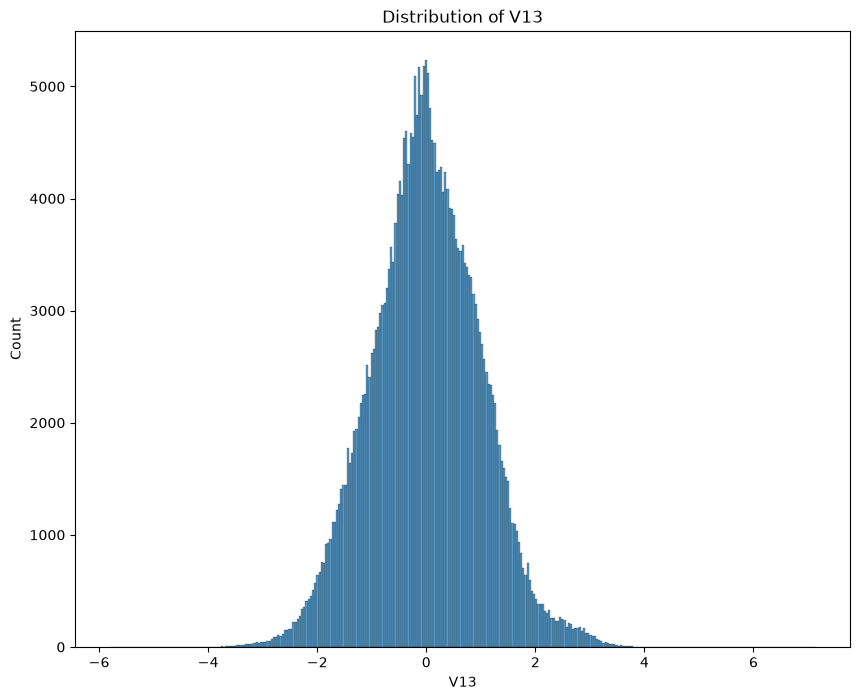

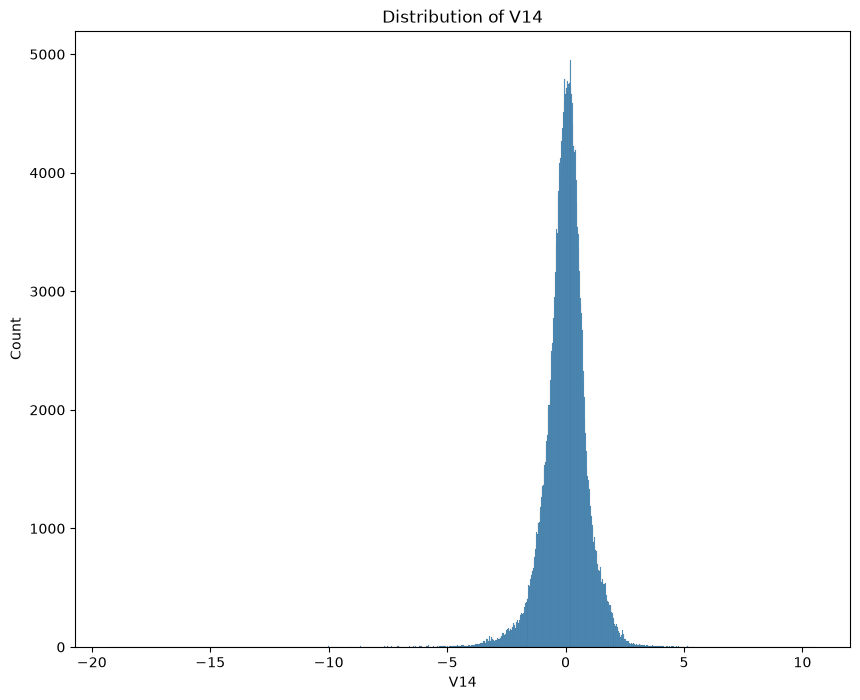

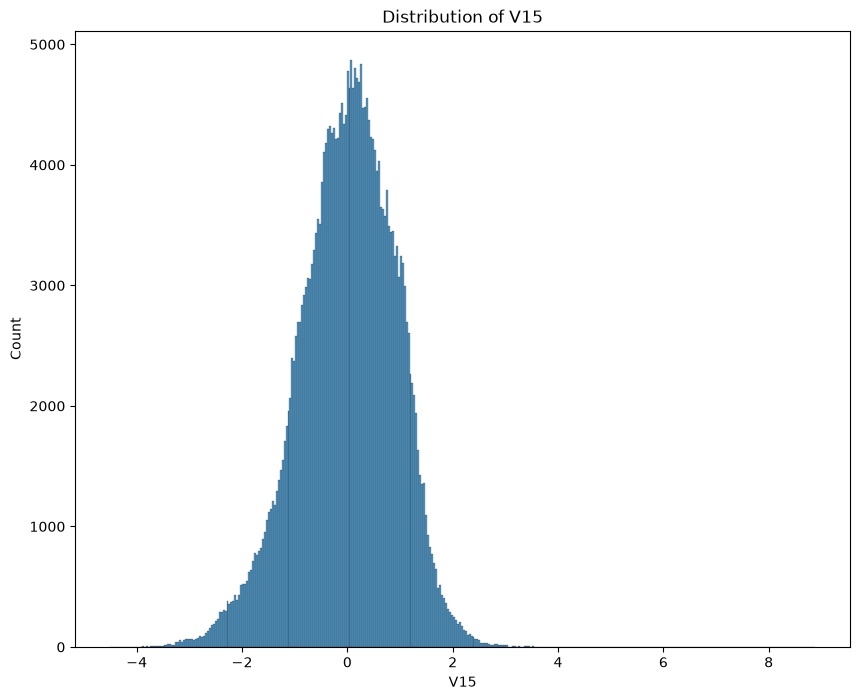

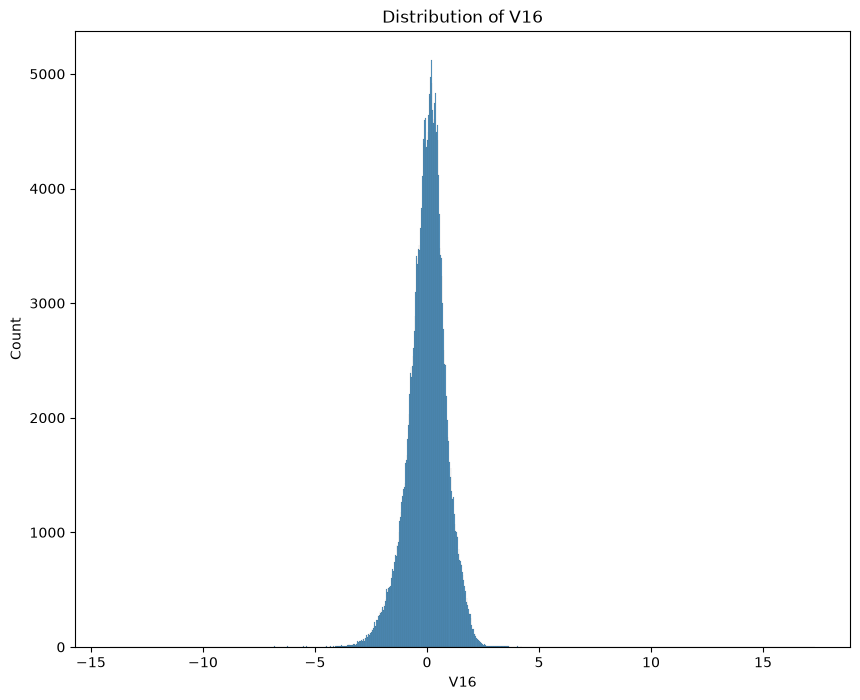

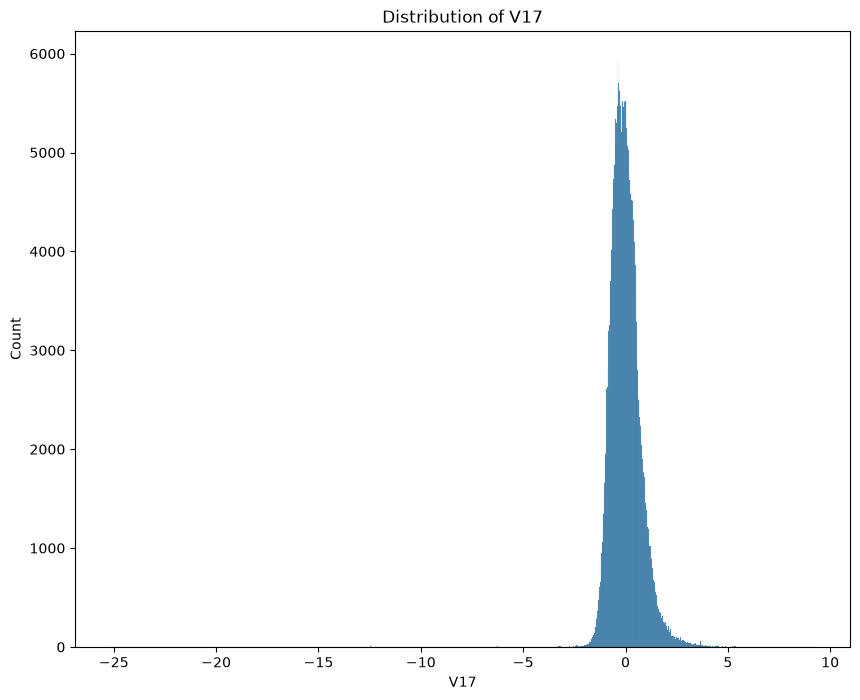

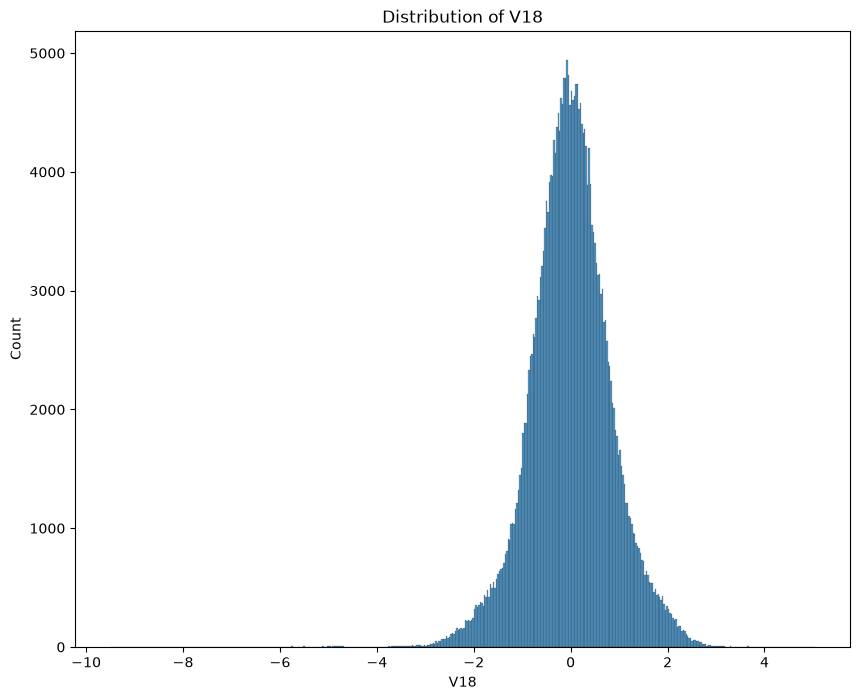

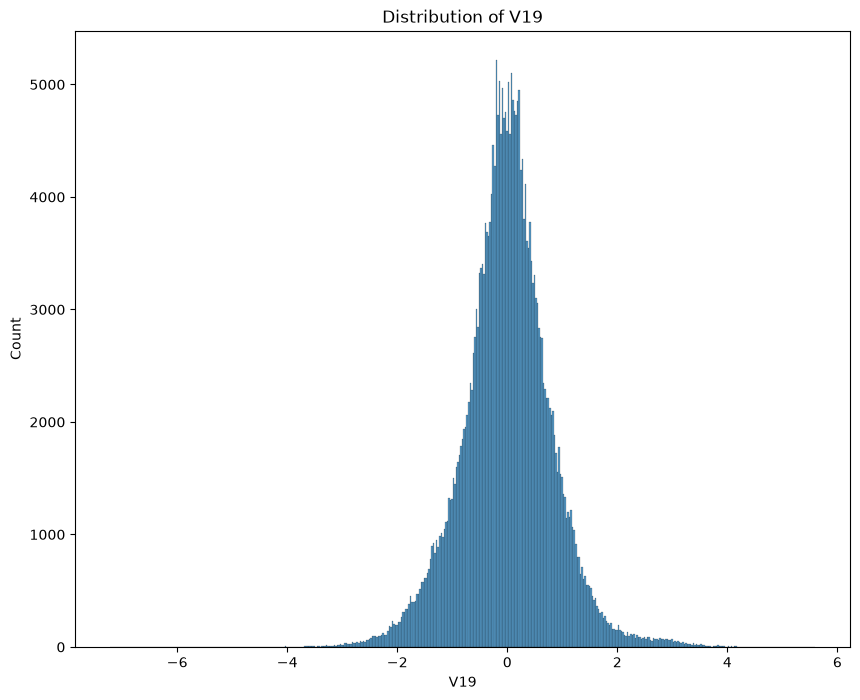

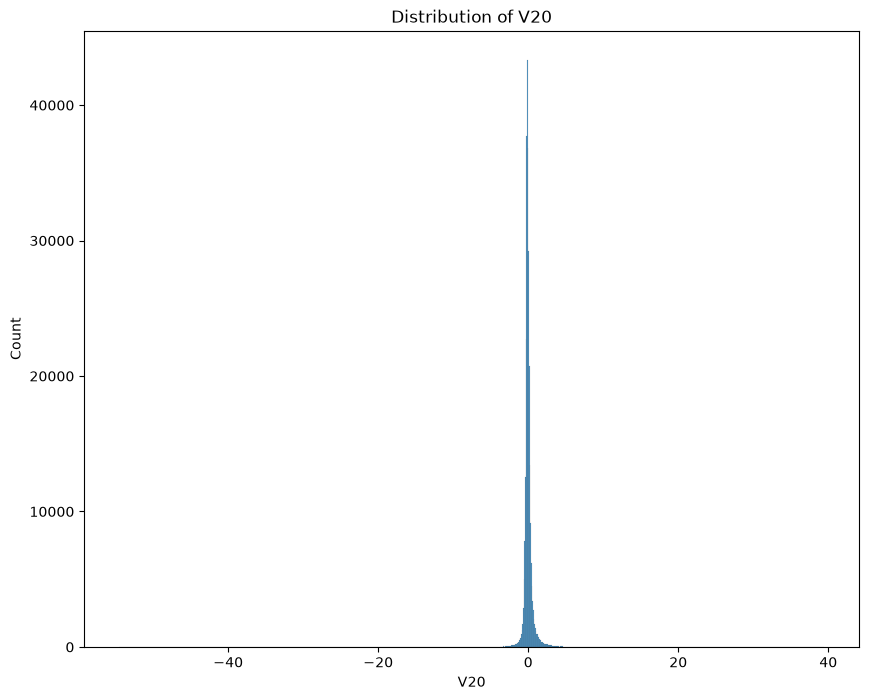

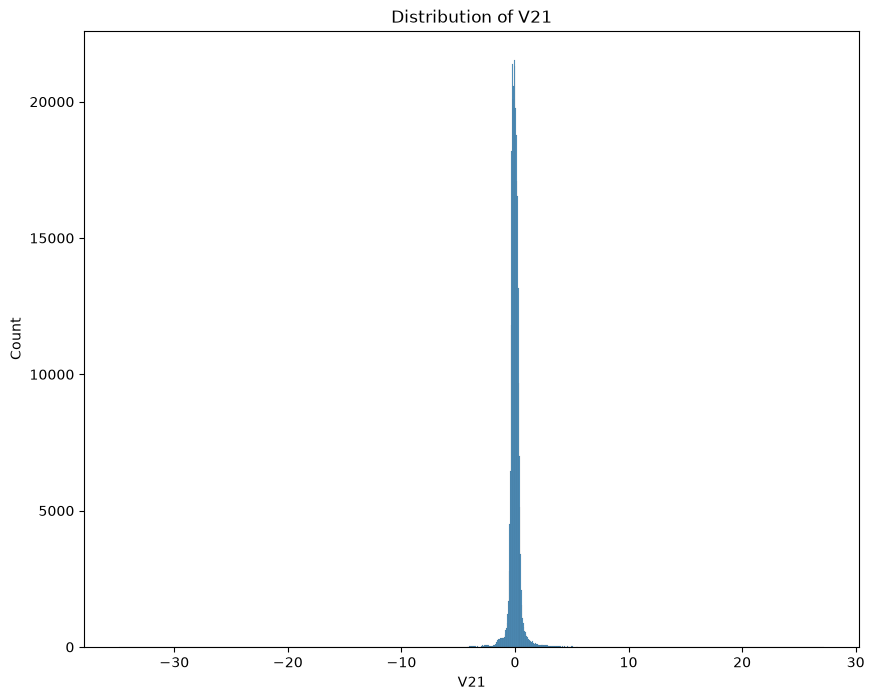

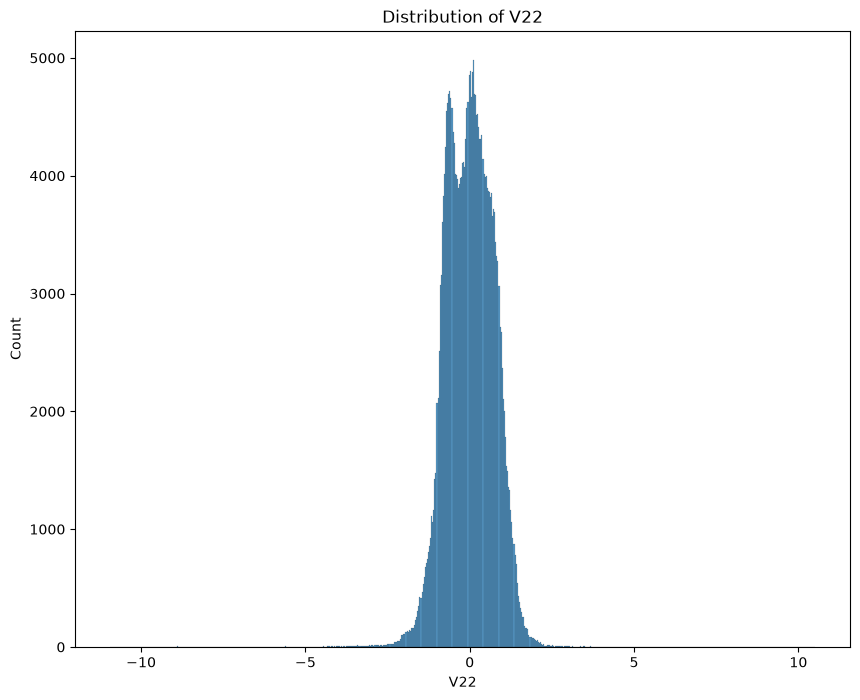

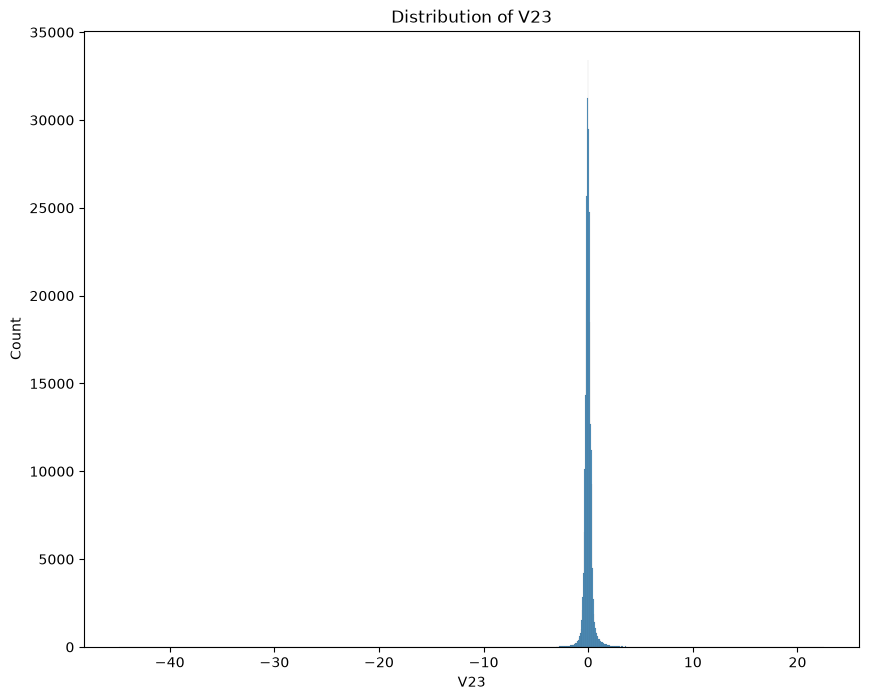

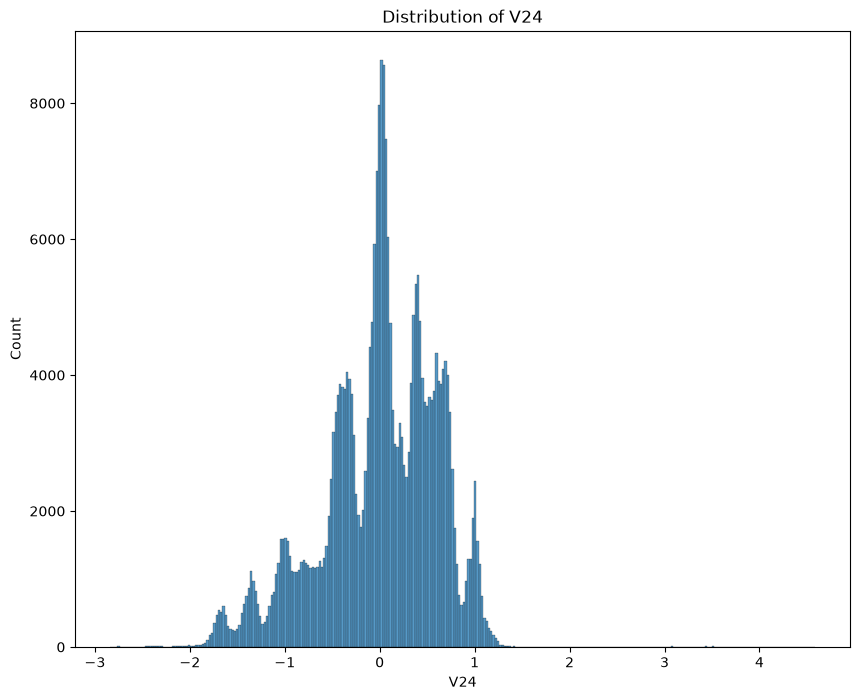

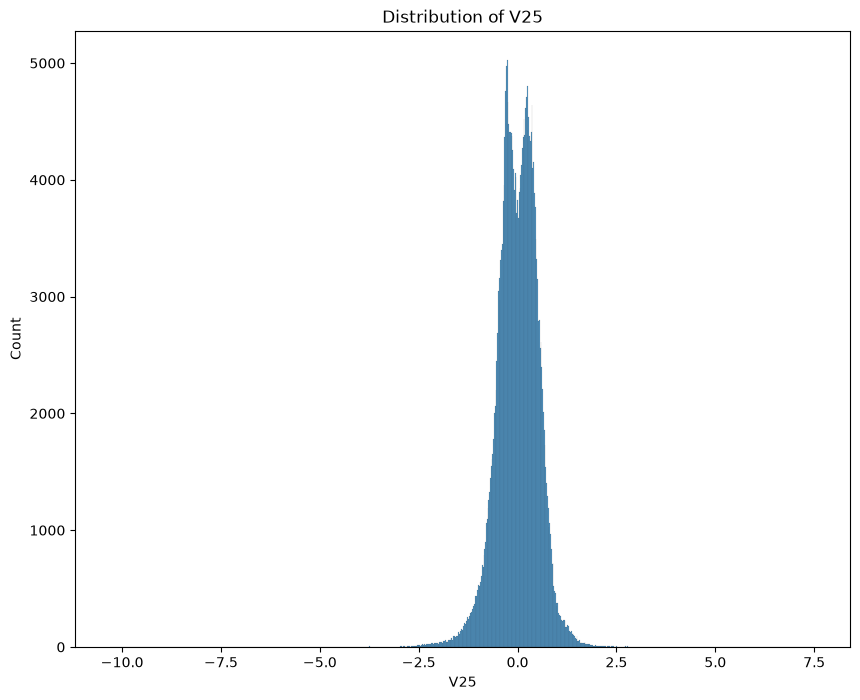

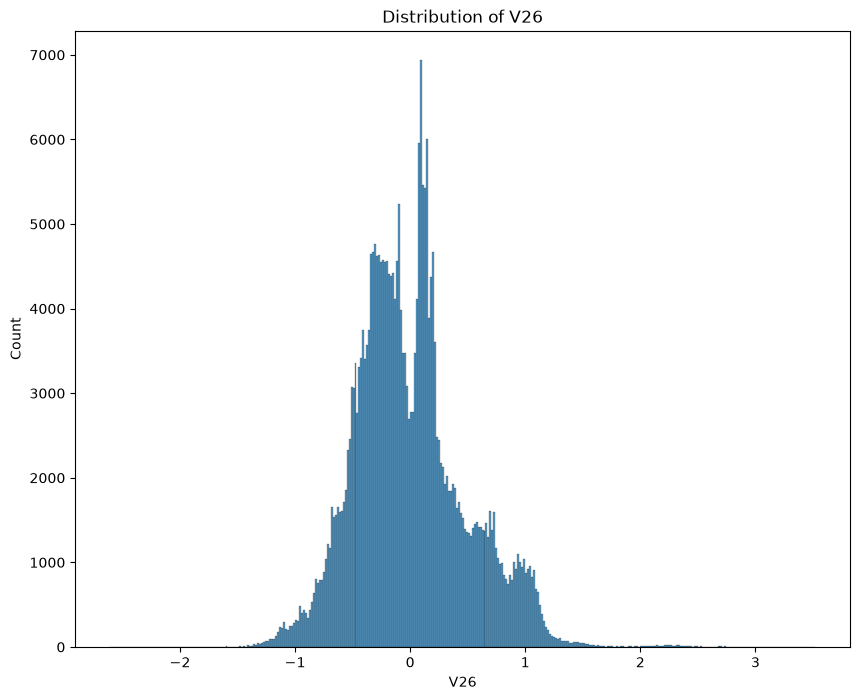

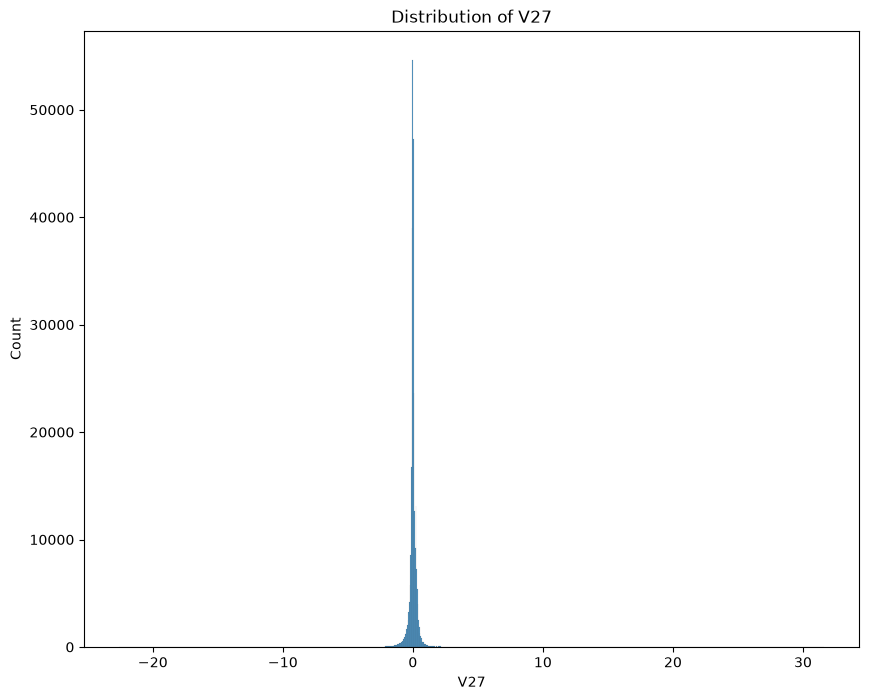

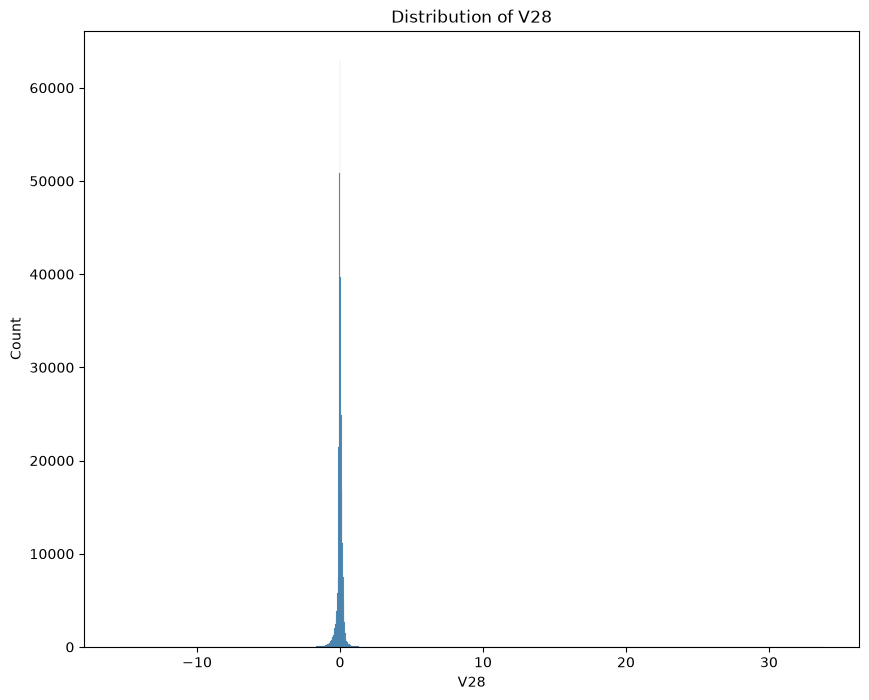

In [18]:
for col in df.columns:
    if col not in ['Time','Amount','Class']:
        plt.figure(figsize=(10, 8))
        sns.histplot(data=df,x = col)
        plt.title(f'Distribution of {col}')
        plt.xlabel(f'{col}')
        plt.ylabel('Count')
        plt.show()


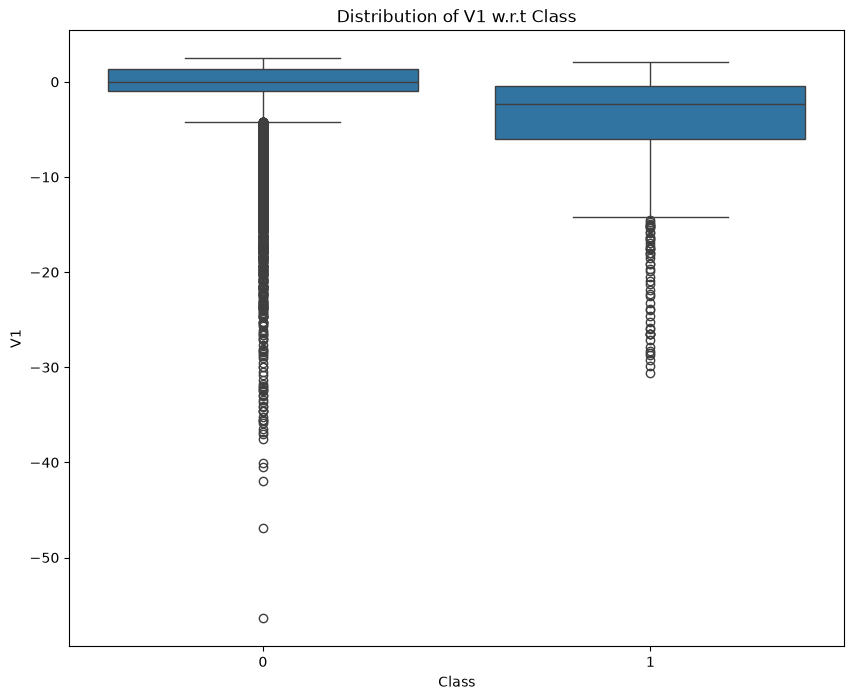

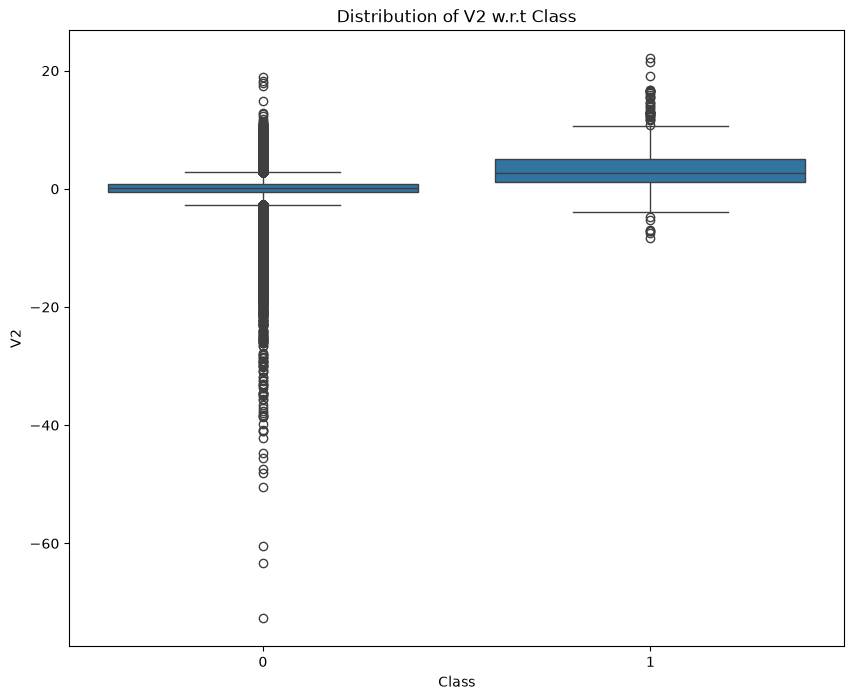

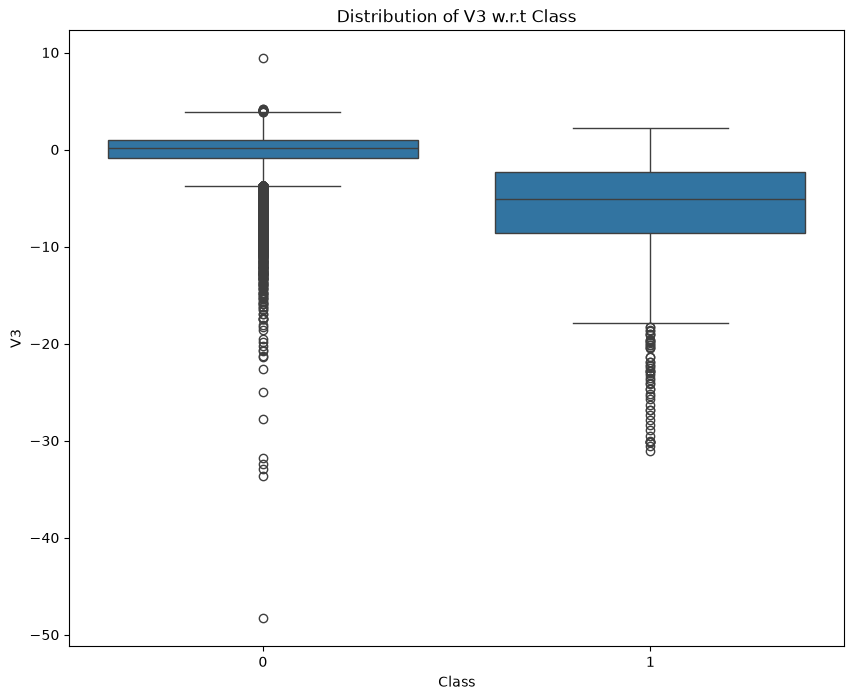

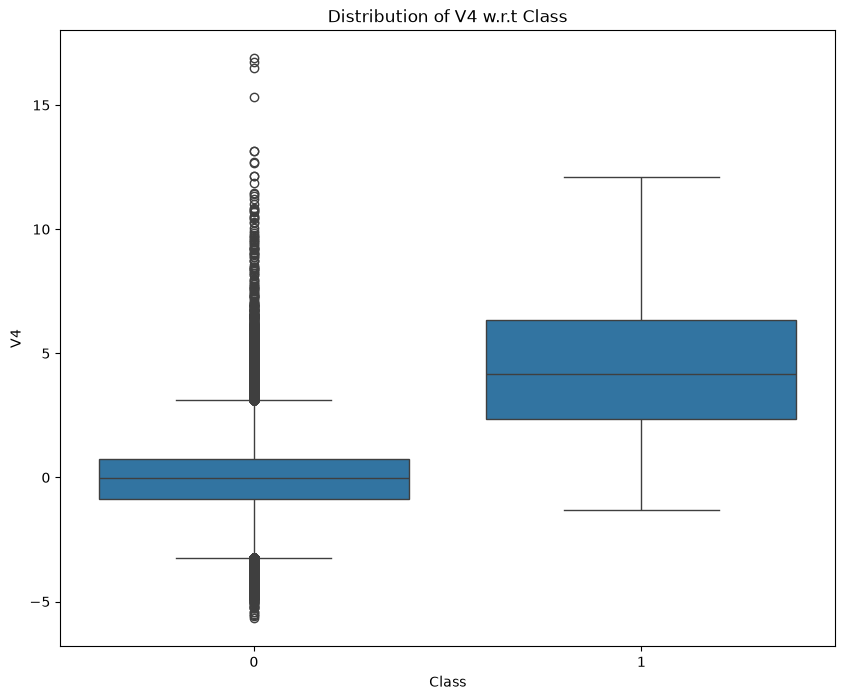

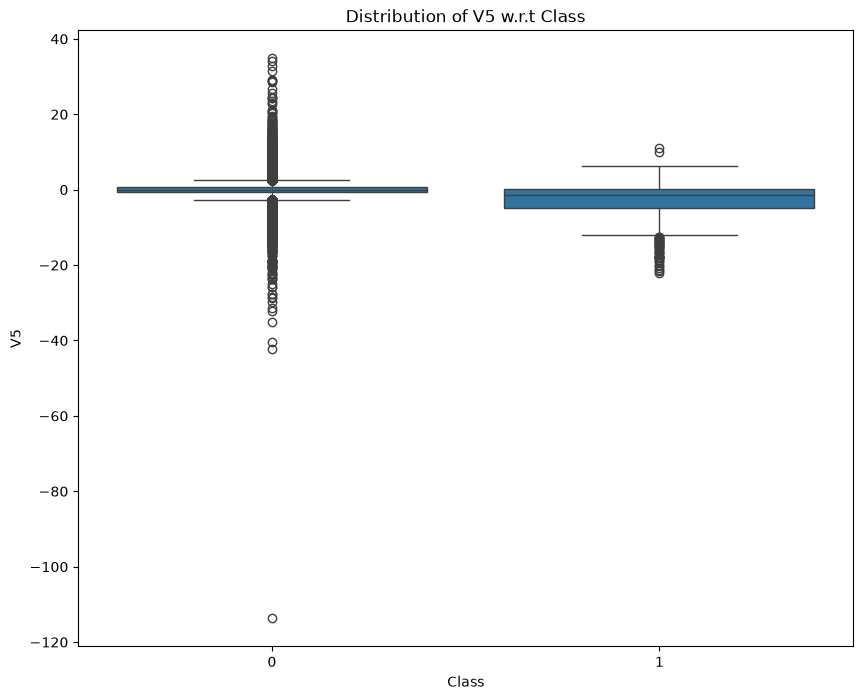

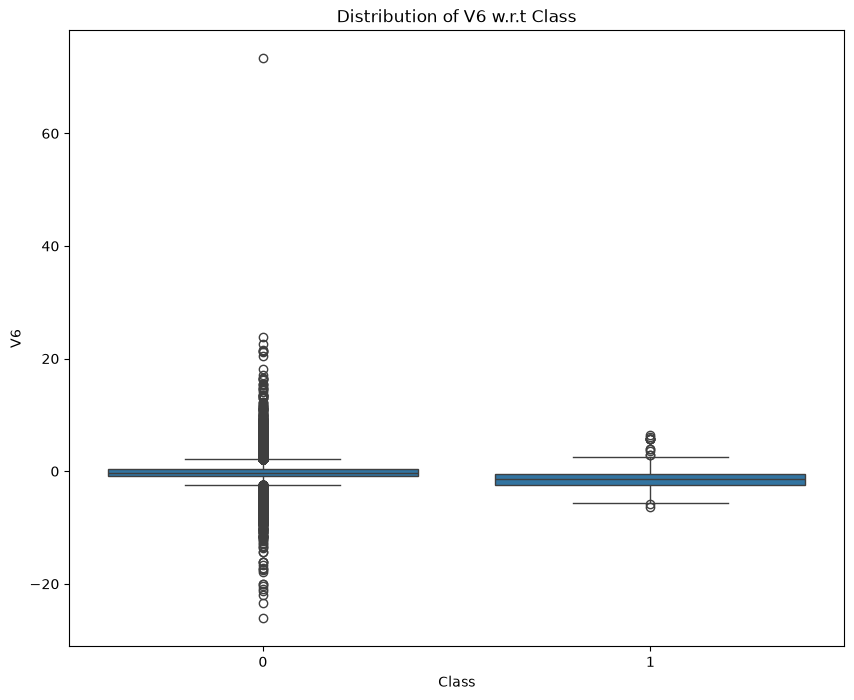

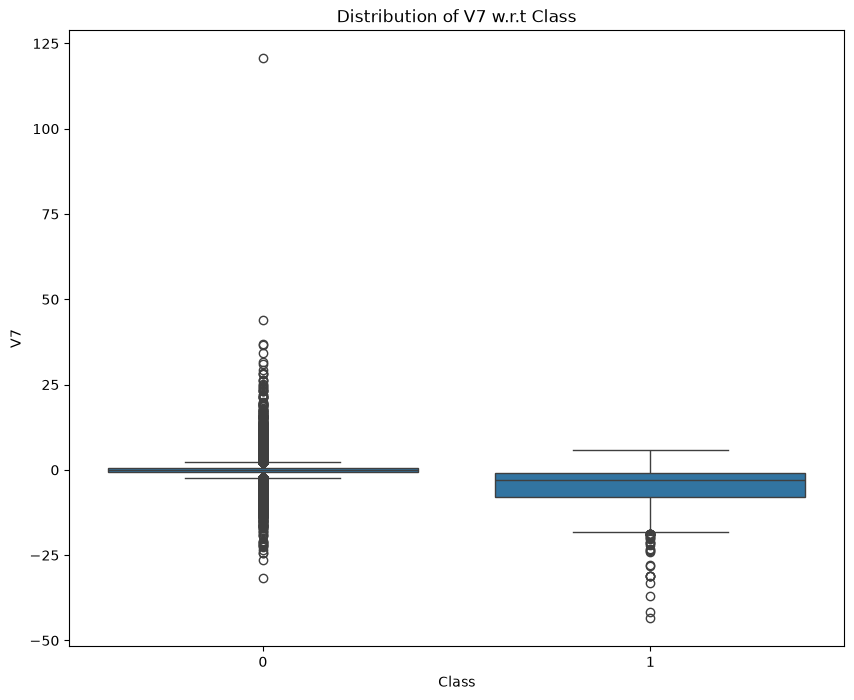

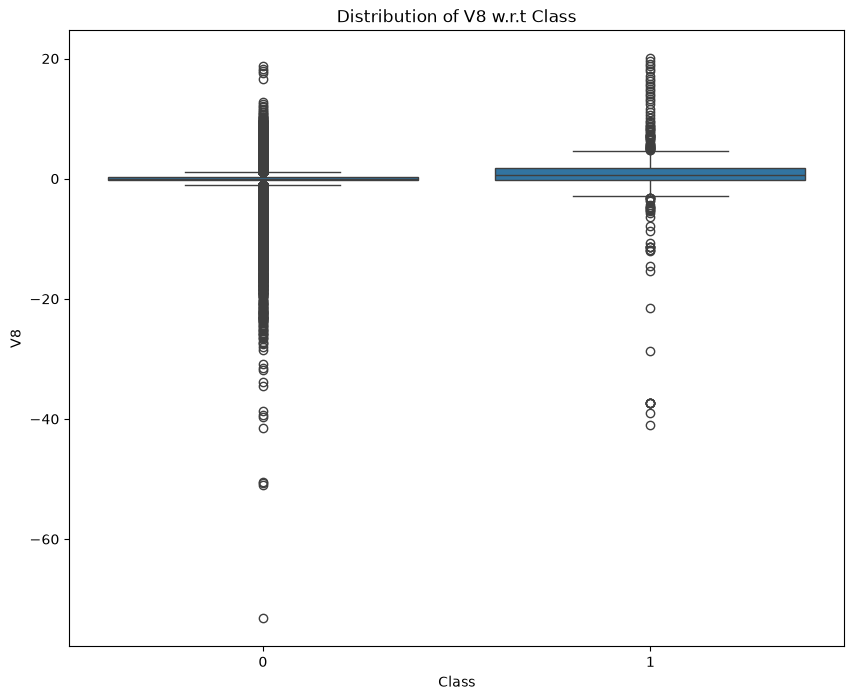

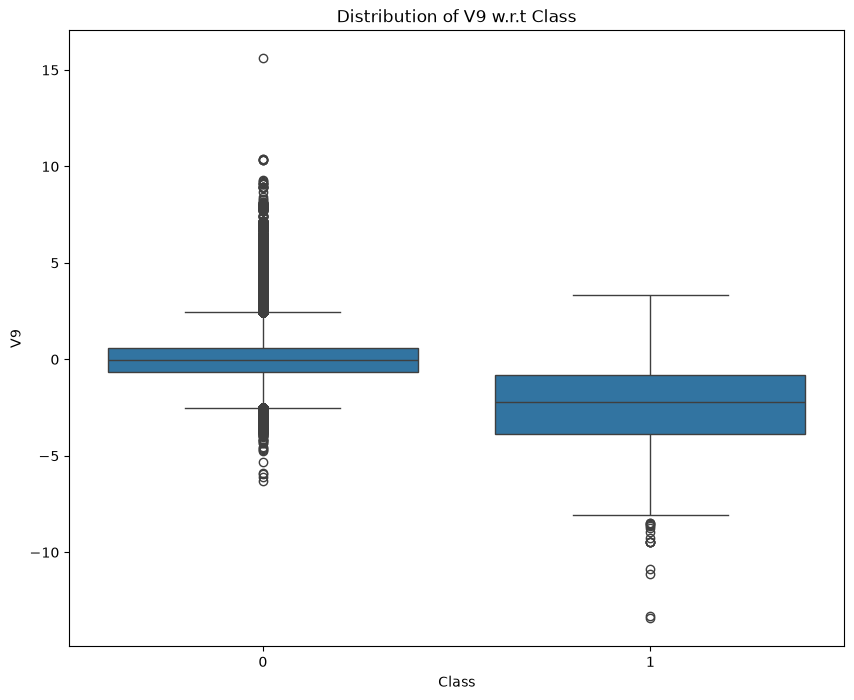

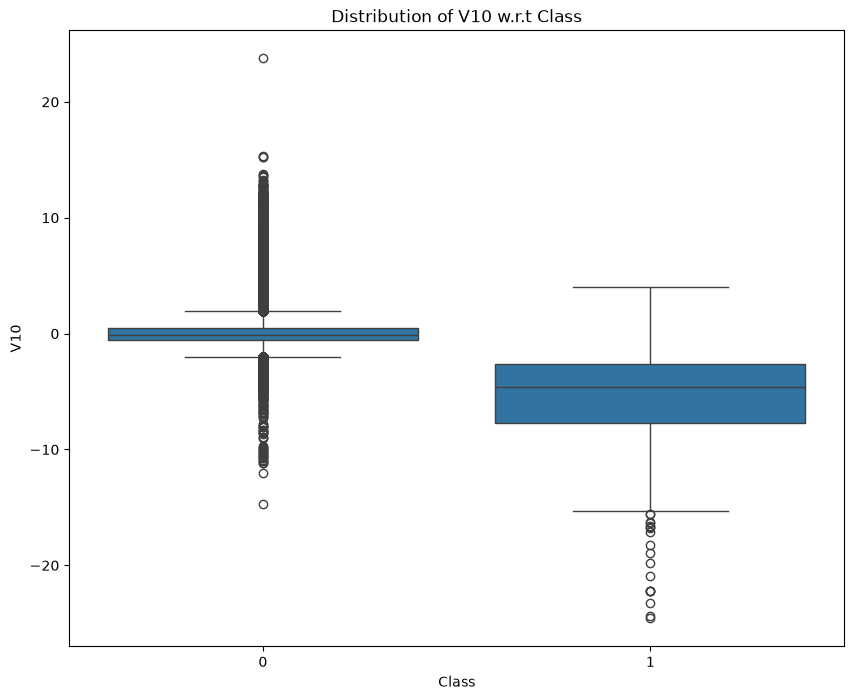

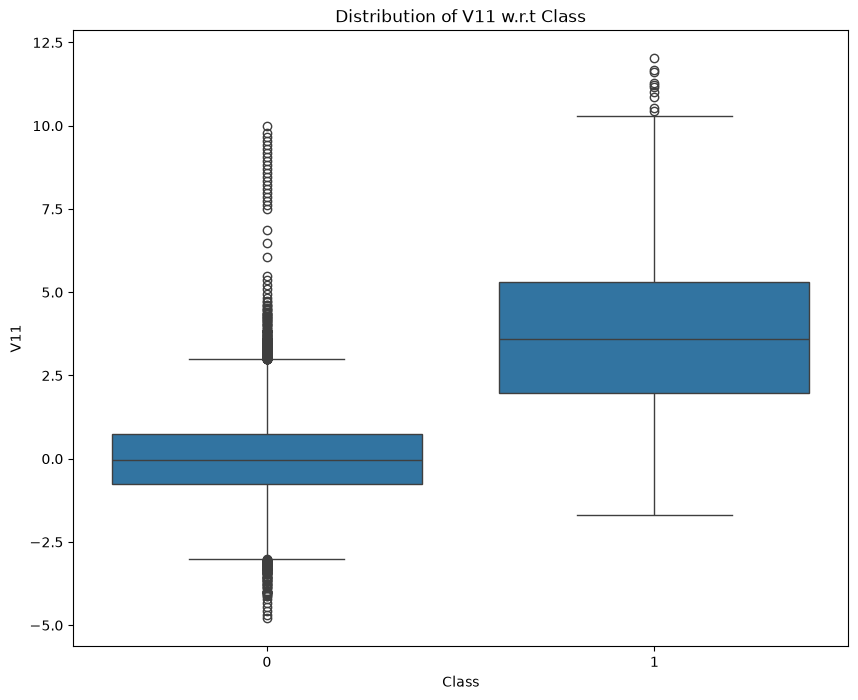

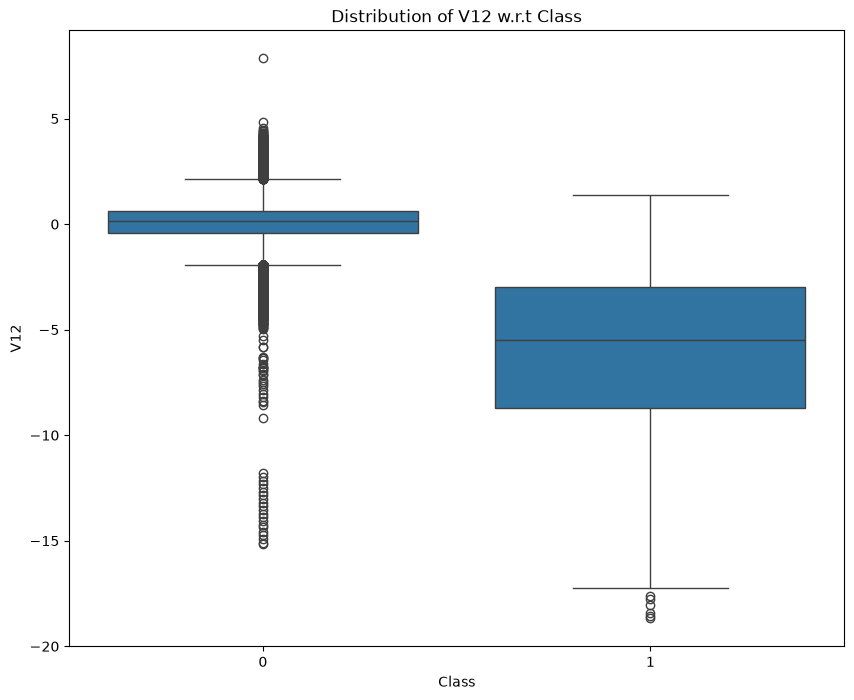

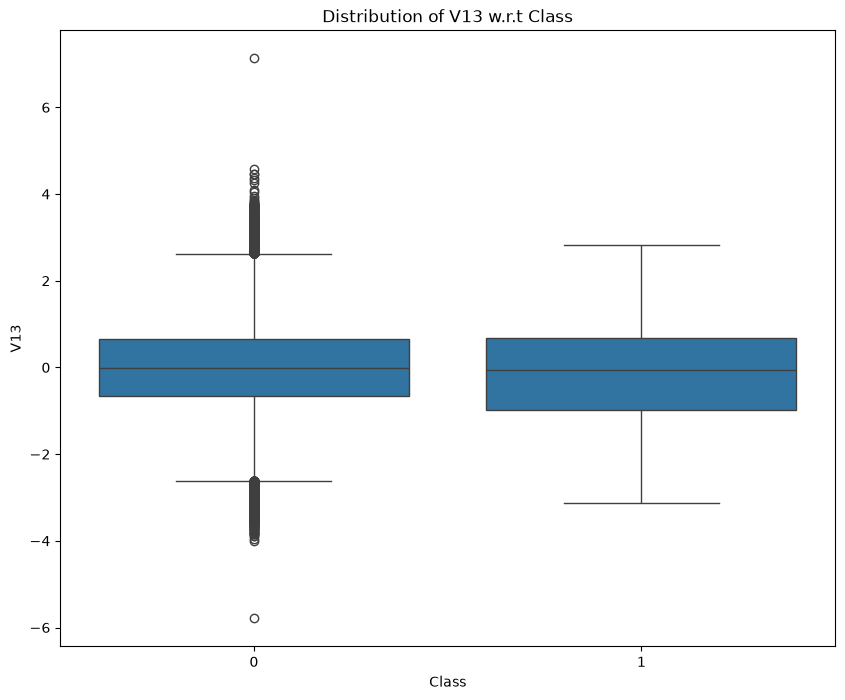

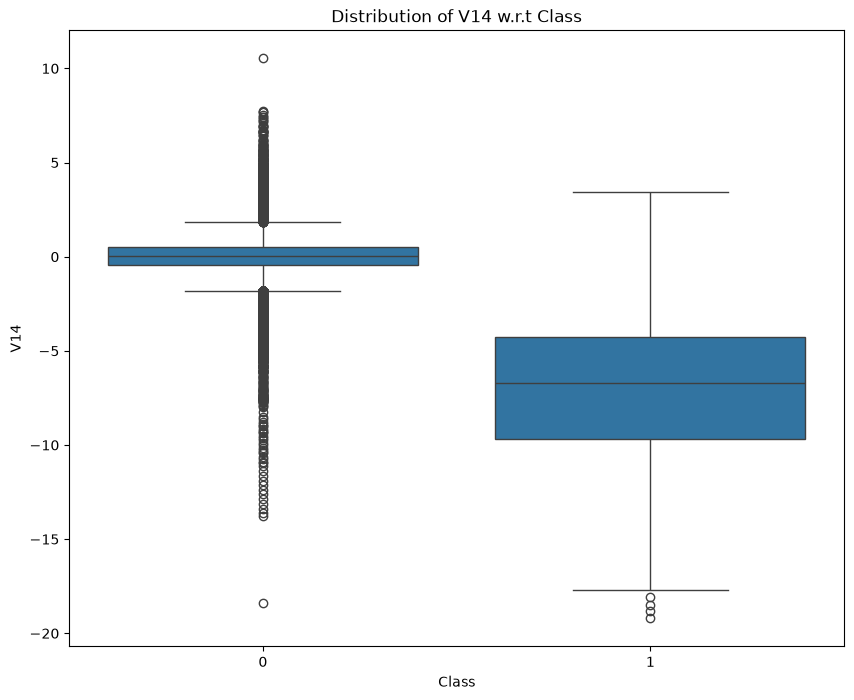

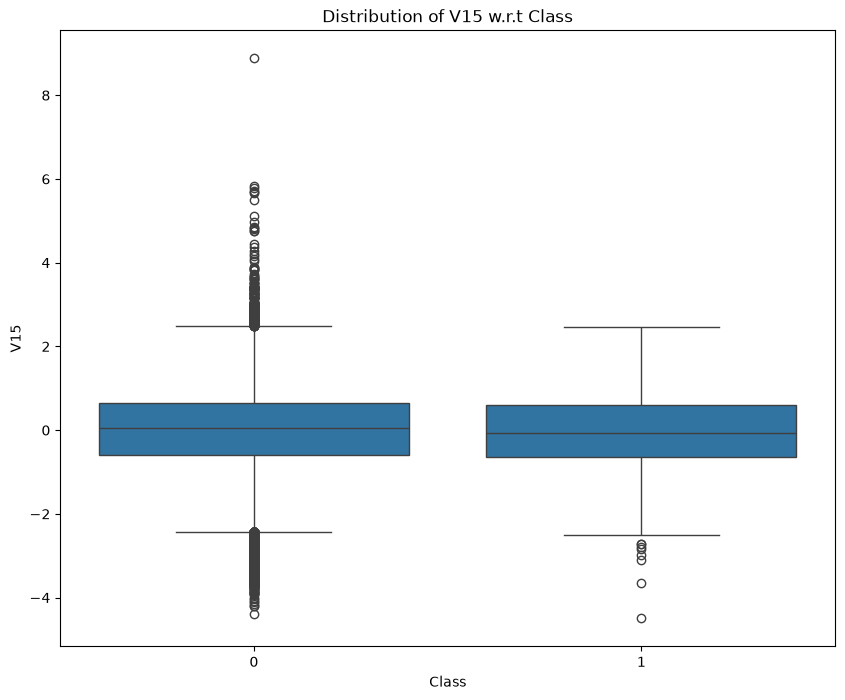

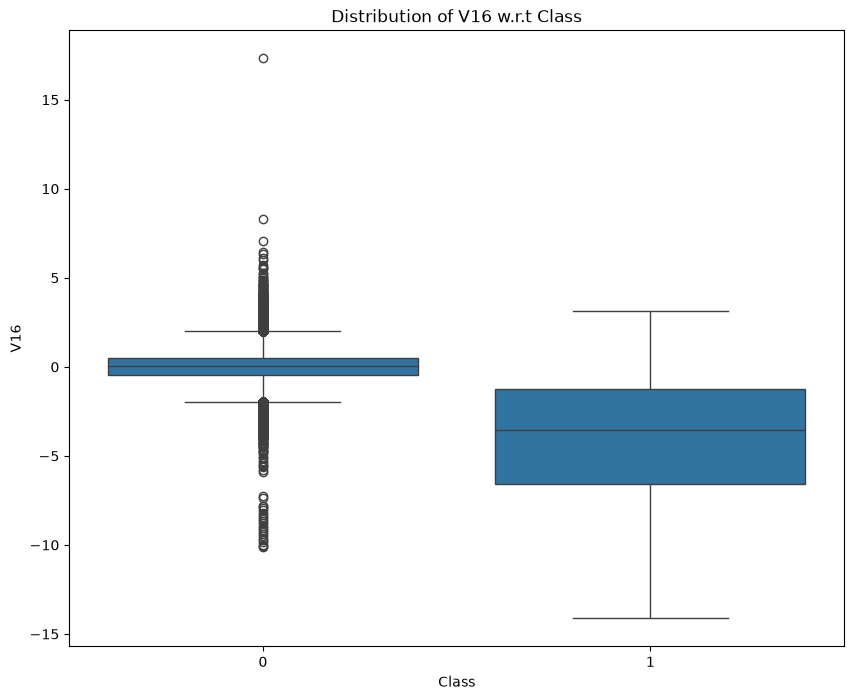

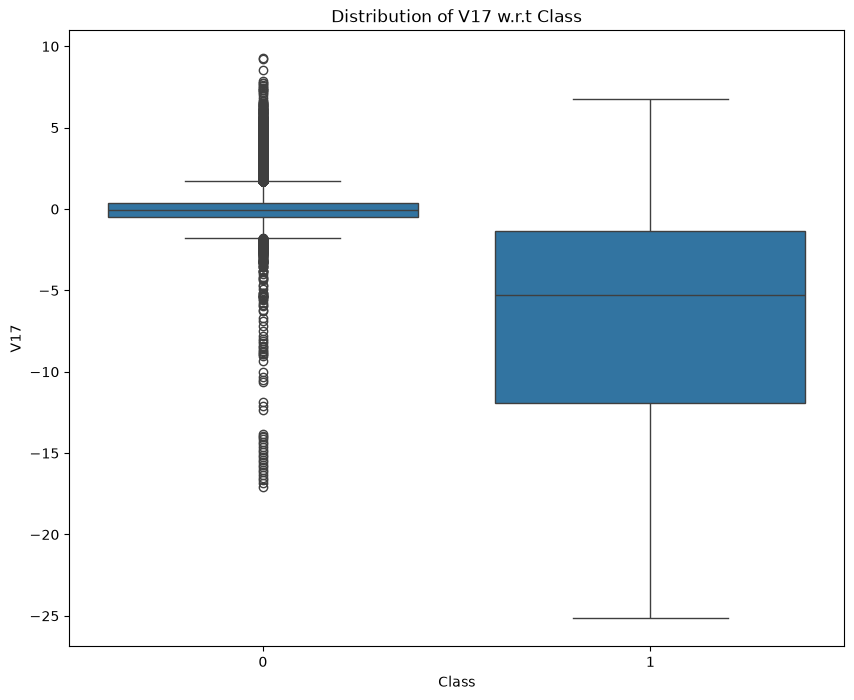

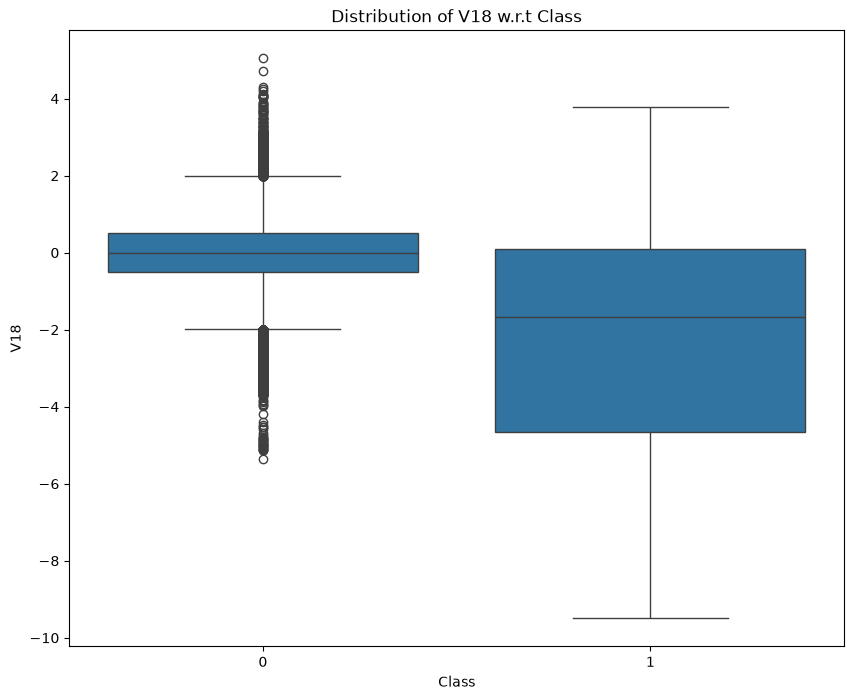

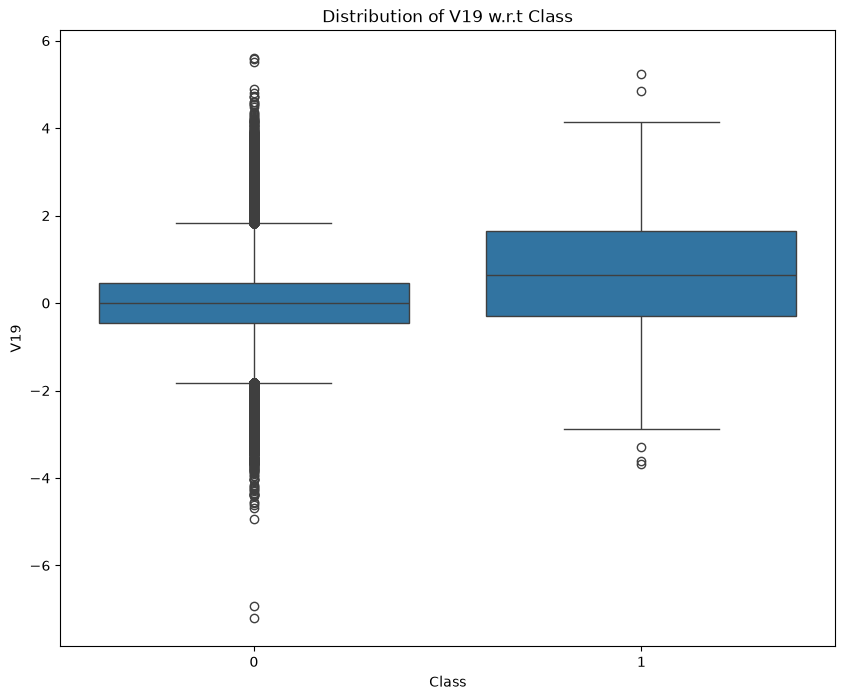

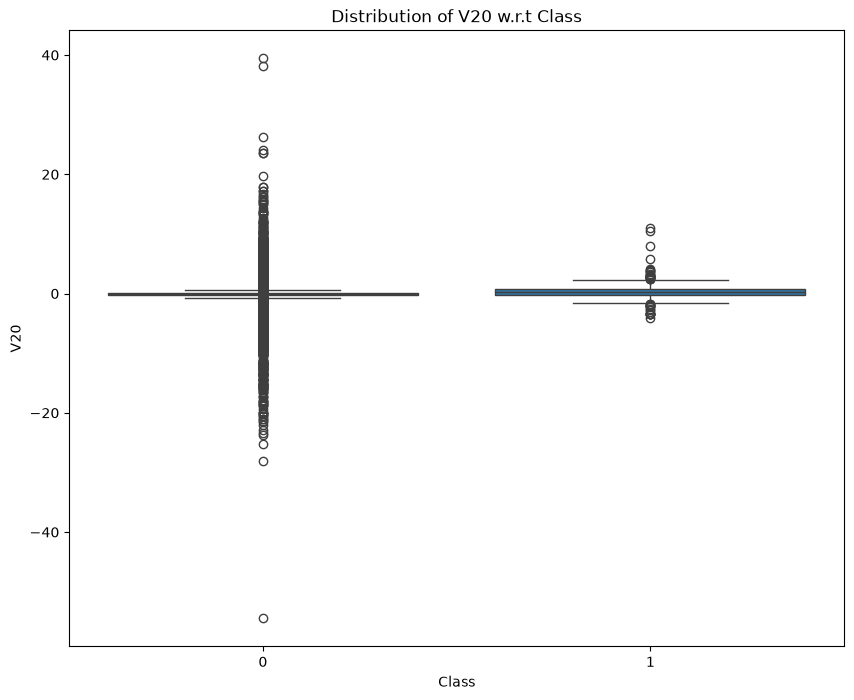

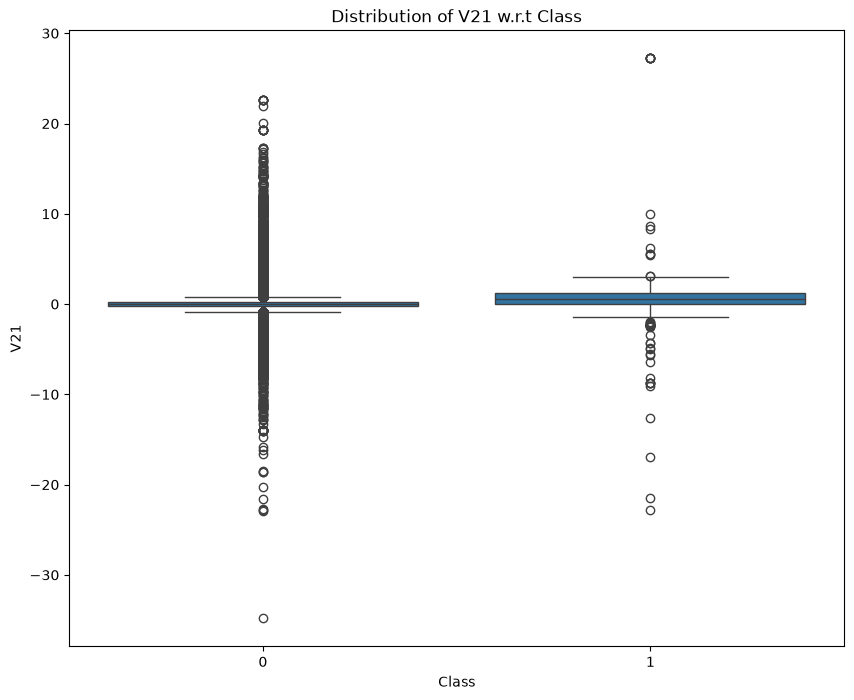

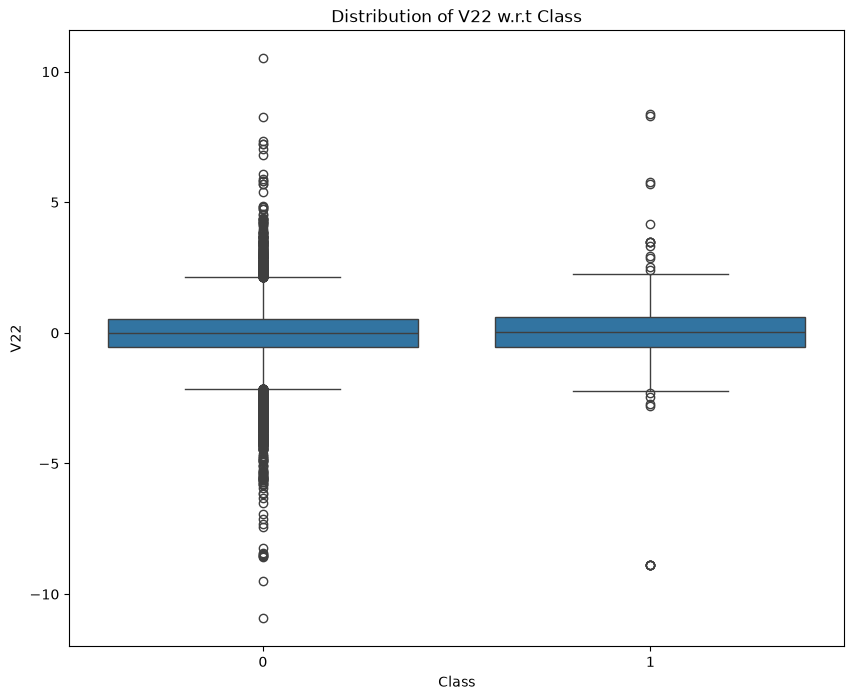

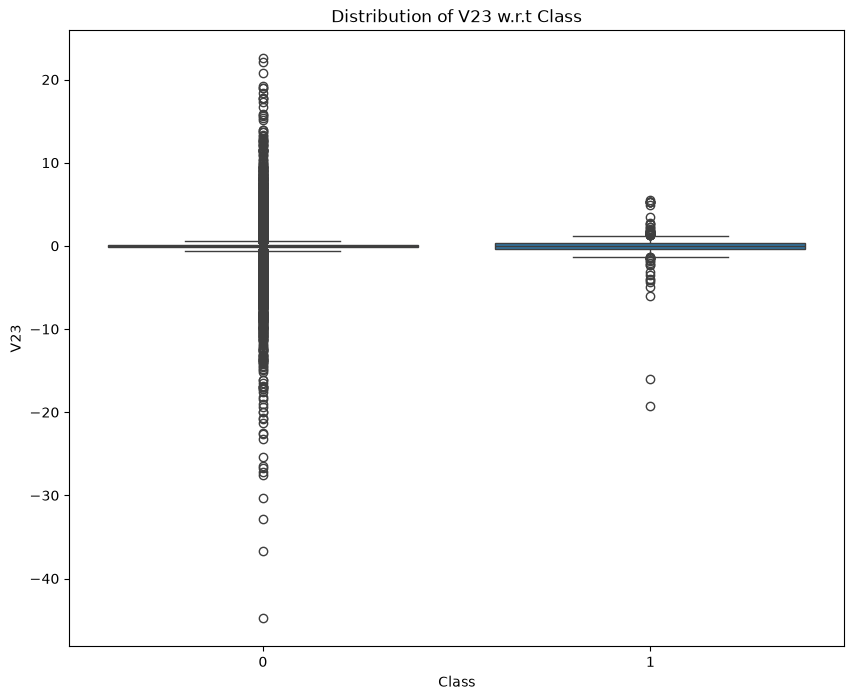

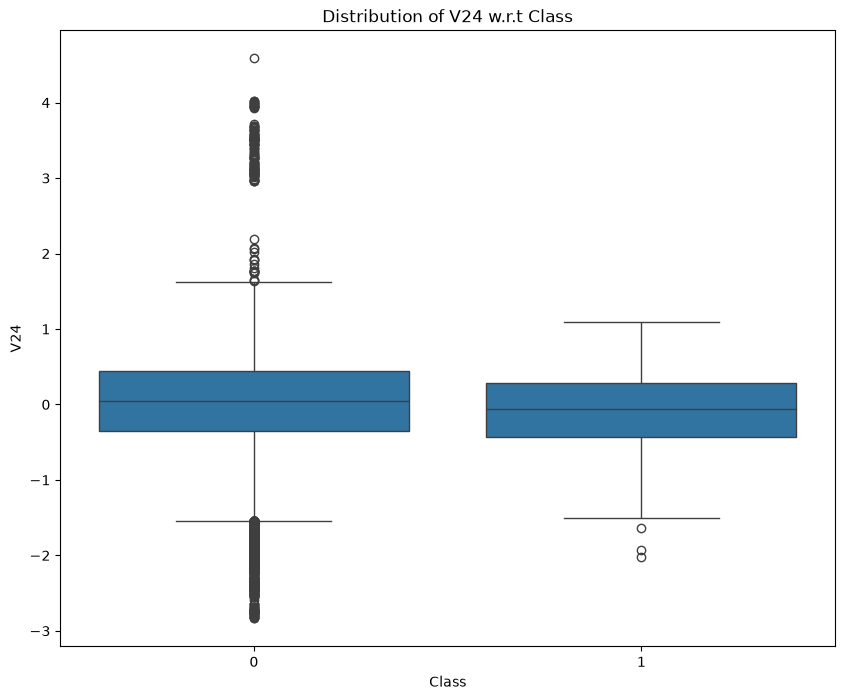

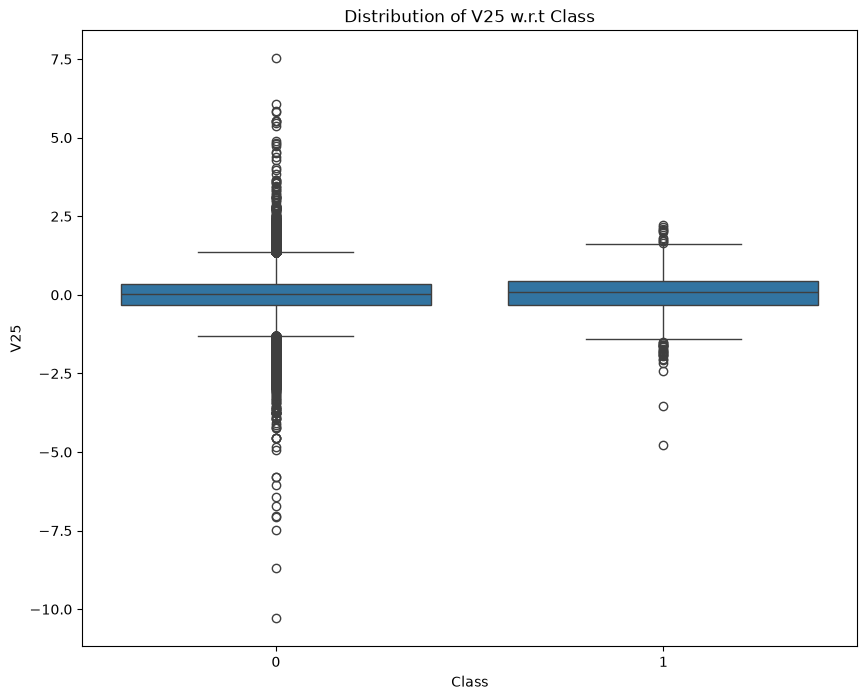

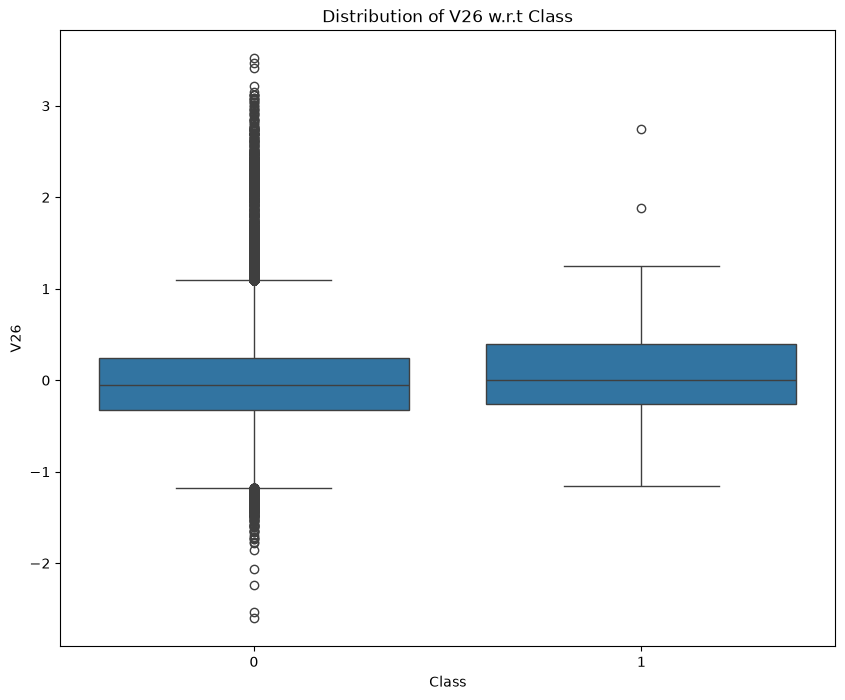

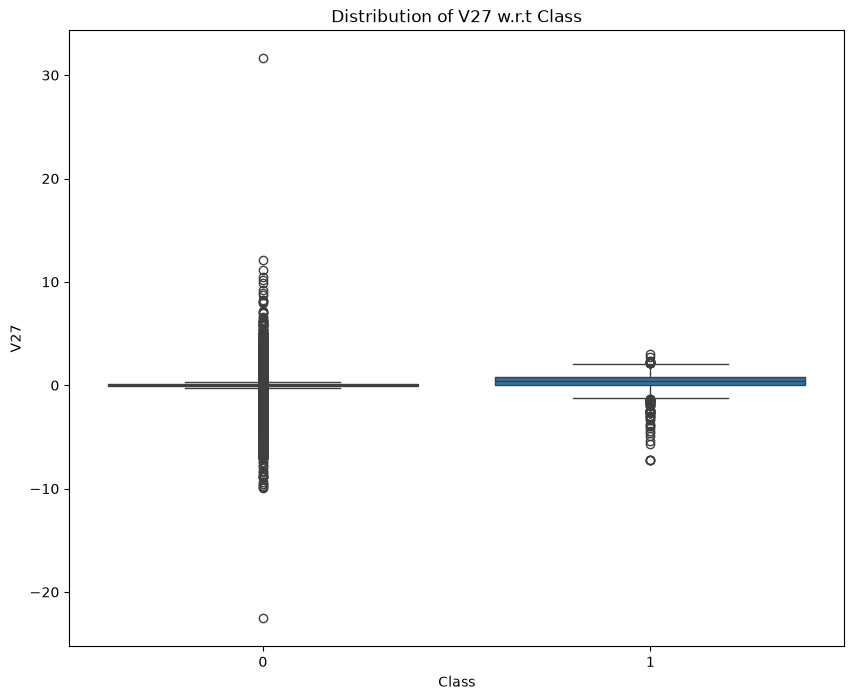

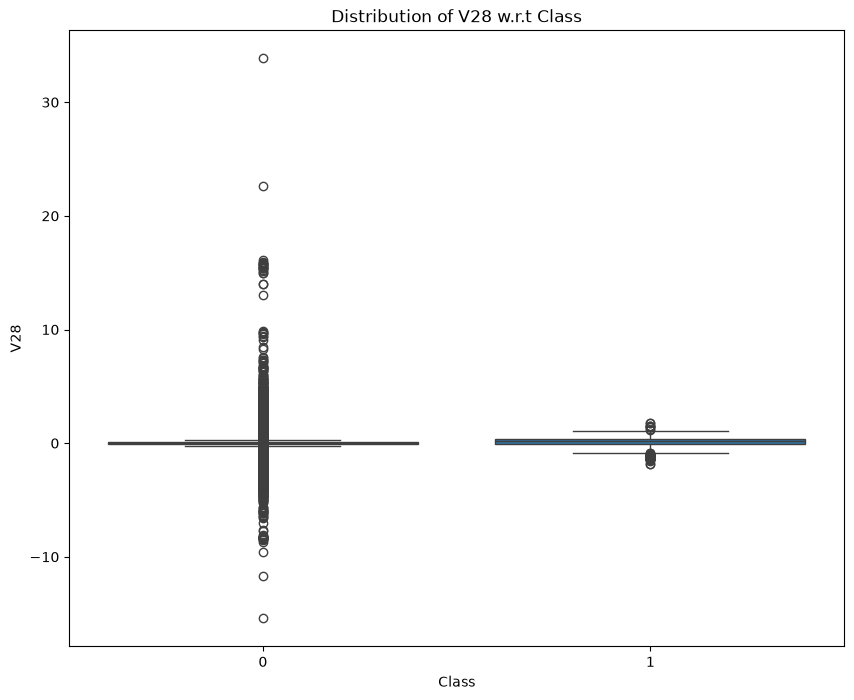

In [19]:

for col in df.columns:
    if col not in ['Time','Amount','Class']:
        plt.figure(figsize=(10, 8))
        sns.boxplot(data=df,x = 'Class',y = col)
        plt.title(f'Distribution of {col} w.r.t Class')
        plt.xlabel("Class")
        plt.ylabel(f'{col}')
        plt.show()


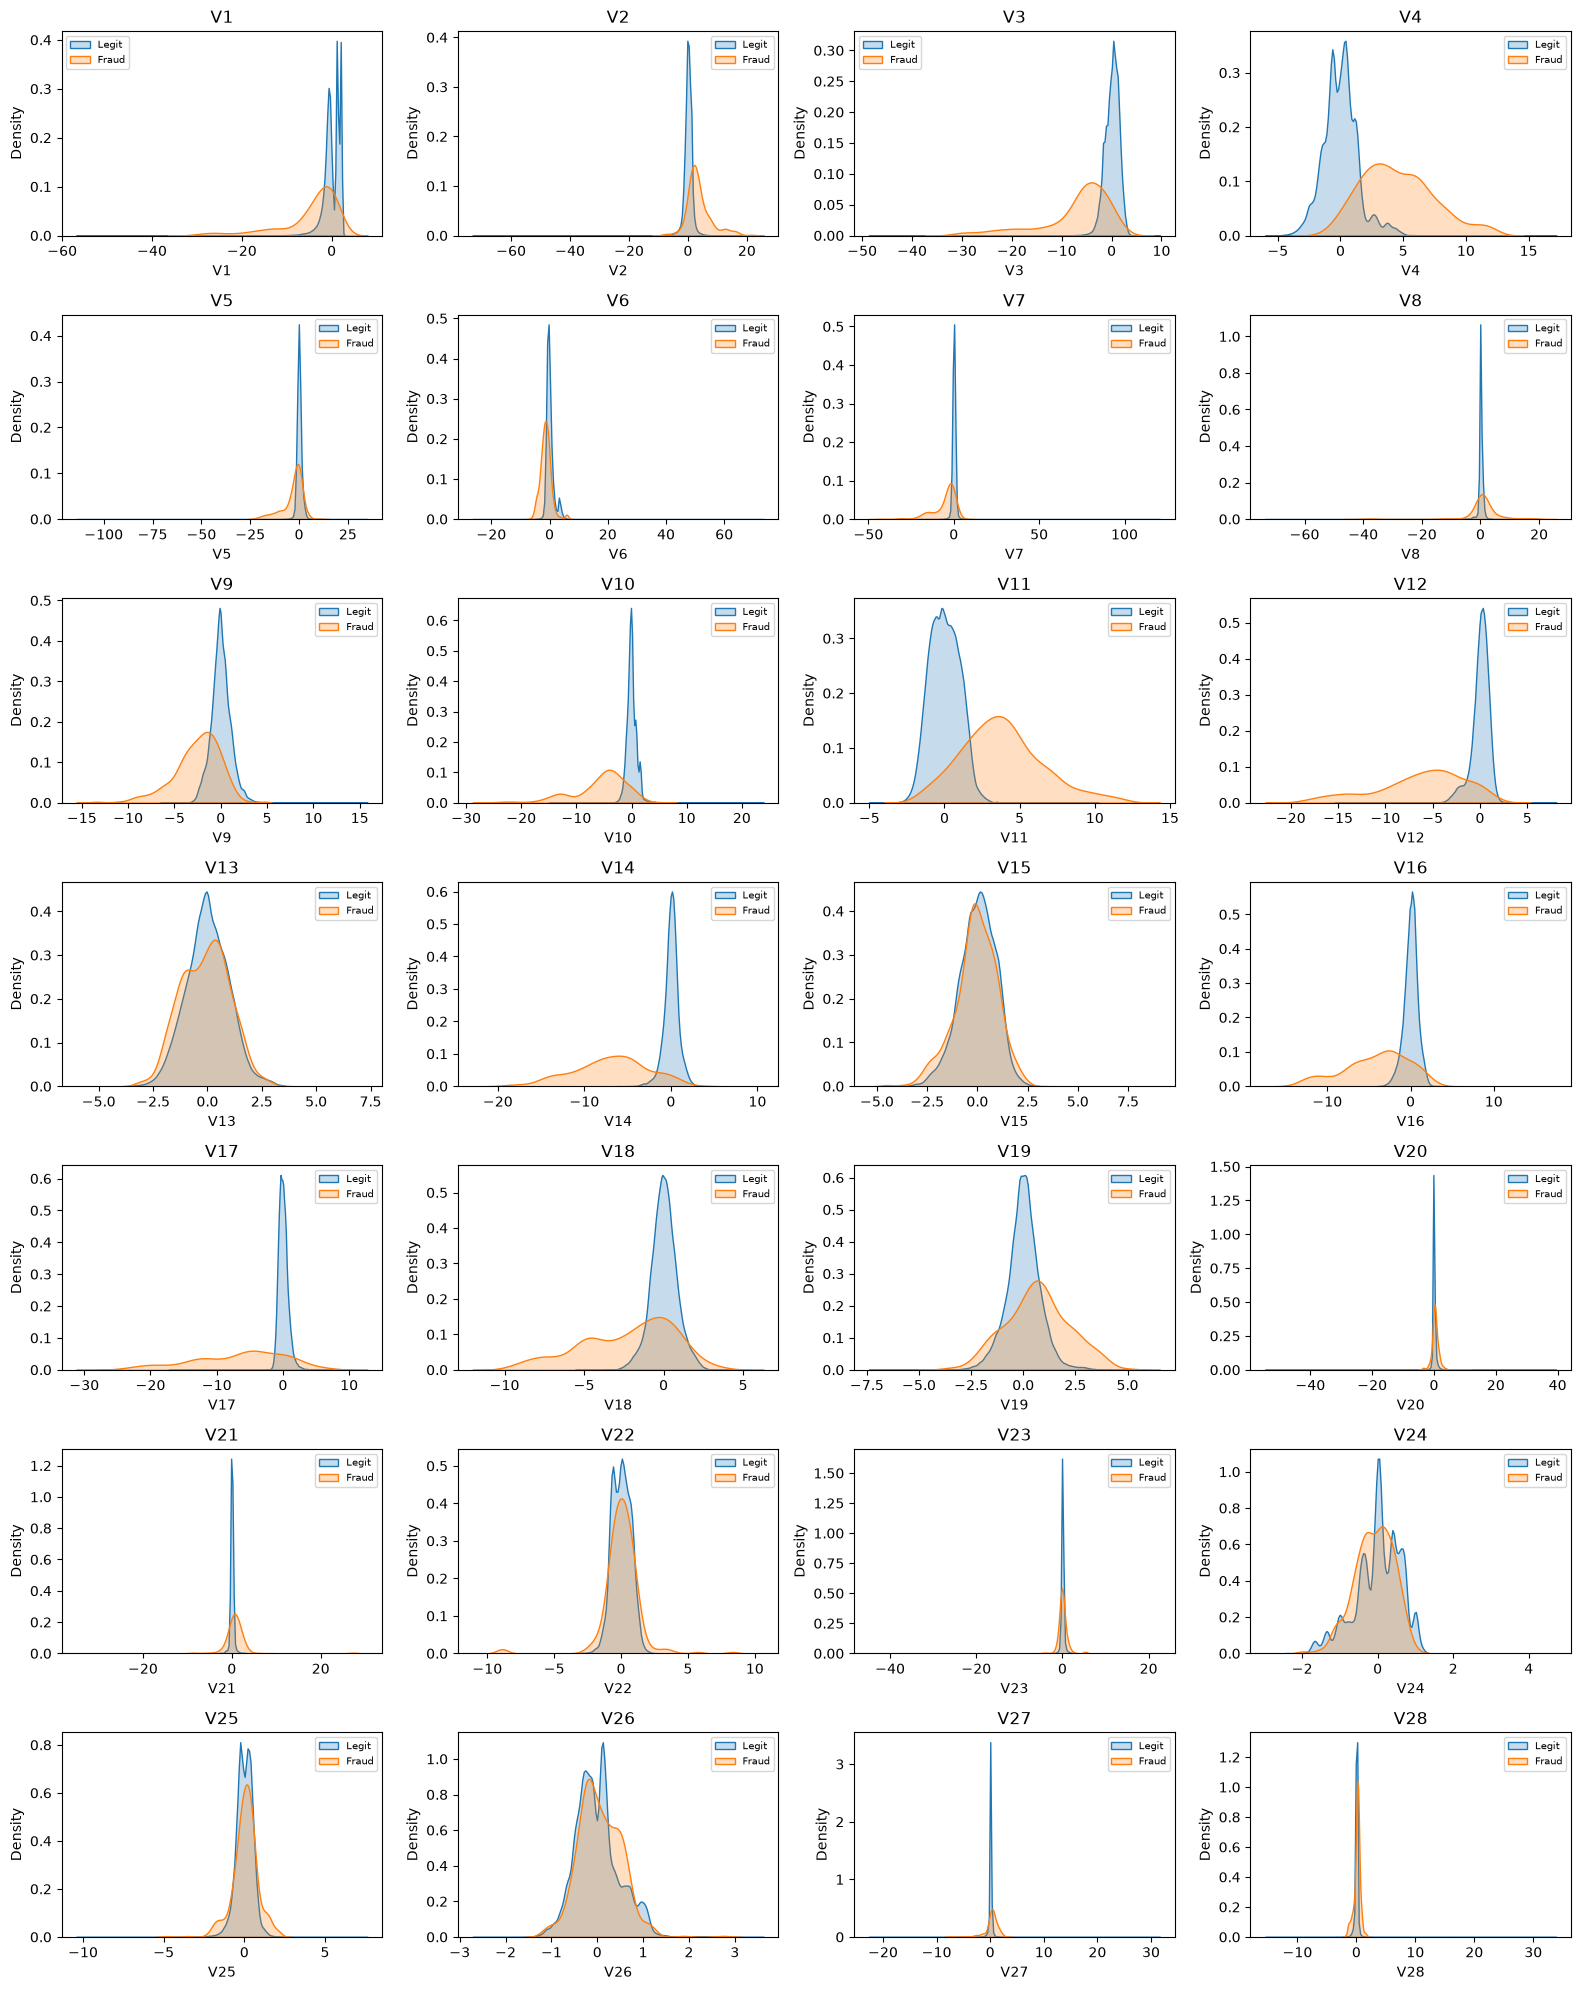

In [20]:
fig, axes = plt.subplots(7, 4, figsize=(16, 20))
for i, col in enumerate([f'V{i}' for i in range(1, 29)]):
    ax = axes[i // 4, i % 4]
    sns.kdeplot(nonfraud[col], ax=ax, label='Legit', fill=True, common_norm=False)
    sns.kdeplot(fraud[col], ax=ax, label='Fraud', fill=True, common_norm=False)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.tight_layout()

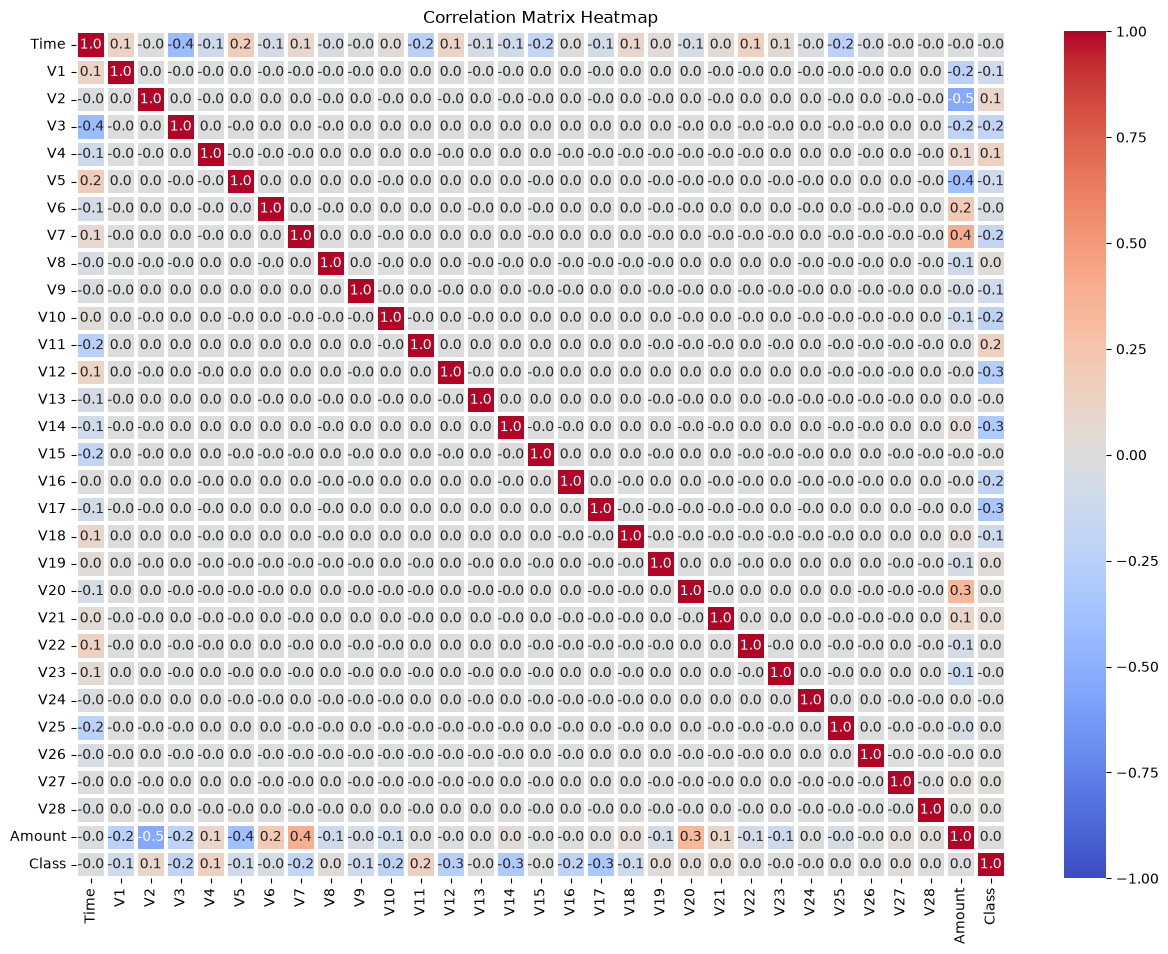

In [21]:
correlation_matrix = df.corr()
# 3. Create the heatmap plot
plt.figure(figsize=(15, 11))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Display the correlation coefficients
    cmap='coolwarm',     # Color map ranging from blue (negative) to red (positive)
    vmin=-1, vmax=1,     # Anchor the colorbar from -1 to 1
    fmt=".1f",           # Limit decimals to 2 places
    linewidths=1.5       # Add lines between grid cells
 )

plt.title("Correlation Matrix Heatmap")
plt.show()

### Conclusion based on EDA
- Highly imbalance dataset
- The amount column is Highly right skewed.

## Data Cleaning

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(283726, 31)

## Splitting the Data(70% train, 15%val,15%test)

In [12]:
X = df.drop(['Class'],axis = 1)
y = df['Class']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)

In [14]:
X_val,X_test,y_val,y_test = train_test_split(X_test,y_test,test_size=0.5,stratify=y_test,random_state=42)

In [15]:
X_test.iloc[0].to_dict()

{'Time': 154309.0,
 'V1': -0.0829834650336291,
 'V2': -3.93591892431521,
 'V3': -2.6167089860612,
 'V4': 0.163310074791927,
 'V5': -1.40095182767067,
 'V6': -0.809419404822953,
 'V7': 1.50157983974791,
 'V8': -0.47099958719182,
 'V9': 1.51974319879361,
 'V10': -1.13445381068391,
 'V11': 0.71387764641859,
 'V12': 0.979674835308759,
 'V13': -1.33903126624009,
 'V14': 0.984993219111346,
 'V15': -0.382470968292812,
 'V16': -0.934615796103053,
 'V17': -0.0524194348357059,
 'V18': 0.51116178431397,
 'V19': 0.731998749113651,
 'V20': 1.87861160253024,
 'V21': 0.70267203994139,
 'V22': -0.182304775613767,
 'V23': -0.921016986180311,
 'V24': 0.111635488151138,
 'V25': -0.0716222119619373,
 'V26': -1.12588109590433,
 'V27': -0.170947427341269,
 'V28': 0.126221382847378,
 'Amount': 1096.99}

In [16]:
y_test.iloc[0]

1

## Feature Engineering

### For amount column

In [15]:
#Log transformation
X_train['Amount'] = np.log1p(X_train['Amount'])
X_val['Amount'] = np.log1p(X_val['Amount'])

In [ ]:
# #Scaling  Amount column
# scaler = RobustScaler()

# X_train['amount_scaled'] = scaler.fit_transform(X_train[['log_transform_amount']])
# X_val['amount_scaled'] = scaler.transform(X_val[['log_transform_amount']])
# X_test['amount_scaled'] = scaler.transform(X_test[['log_transform_amount']])


In [16]:
#Scaling both Amount column
amount_scaler = RobustScaler()

X_train['Amount'] = amount_scaler.fit_transform(X_train[['Amount']])
X_val['Amount'] = amount_scaler.transform(X_val[['Amount']])


In [17]:
with open('amount_scaler.pkl','wb') as f_out:
    pickle.dump(amount_scaler,f_out)

In [18]:
#Scaling both Time column
time_scaler = RobustScaler()

X_train['Time'] = time_scaler.fit_transform(X_train[['Time']])
X_val['Time'] = time_scaler.transform(X_val[['Time']])


In [19]:
with open('time_scaler.pkl','wb') as f_out:
    pickle.dump(time_scaler,f_out)

In [20]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
257334,0.860849,2.139297,-2.379957,-0.588094,-2.116887,-0.151810,4.930636,-3.133495,1.408309,0.431508,...,-0.379746,-0.073778,0.629693,0.241327,0.738886,-0.314844,0.044060,0.139812,-0.034152,-0.188669
118498,-0.114632,-2.150992,0.447565,0.584405,1.181052,0.180772,-1.200828,-0.106578,0.771604,-1.441208,...,0.028937,-0.066225,-0.869480,-0.041398,0.501689,-0.198083,-0.732049,-0.234089,-0.221309,-1.266068
120679,-0.105008,-6.000510,-5.868708,-1.210423,2.234168,-0.925608,0.019870,0.012067,0.910109,-0.905567,...,0.545803,-0.132715,-0.755490,0.460192,-0.747164,-0.243348,-0.205593,0.915416,-1.136679,1.283054
163000,0.360782,2.021325,-0.535640,-0.416146,-0.124310,-0.178832,0.918878,-1.042599,0.318182,1.072180,...,-0.078728,0.020950,0.209552,0.220896,-0.311931,-0.459092,0.495448,-0.012725,-0.051766,-0.992757
171948,0.423403,0.149536,0.807852,-0.590906,-0.509802,1.145394,-1.116329,0.935687,-0.234237,0.014499,...,-0.122272,0.220651,0.679815,-0.349294,-0.734172,0.185243,-0.114120,0.027129,0.015322,-0.571227


In [21]:
pca_scaler = RobustScaler()

v_cols = [f"V{i}" for i in range(1,29)]
X_train[v_cols] = pca_scaler.fit_transform(X_train[v_cols])
X_val[v_cols] = pca_scaler.transform(X_val[v_cols])

In [22]:
with open('pca_scaler.pkl','wb') as f_out:
    pickle.dump(pca_scaler,f_out)

In [23]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
257334,0.860849,0.951192,-1.743843,-0.400152,-1.314933,-0.076600,4.466154,-2.822466,2.592138,0.390816,...,-0.921676,-0.107869,0.581873,0.815759,0.878472,-0.494374,0.169111,0.854143,-0.348011,-0.188669
118498,-0.114632,-0.971781,0.273230,0.212525,0.754925,0.178770,-0.793343,-0.131307,1.401426,-1.120603,...,0.264245,-0.089664,-0.818281,-0.096735,0.579845,-0.319757,-1.202814,-1.454033,-1.773273,-1.266068
120679,-0.105008,-2.697195,-4.232619,-0.725344,1.415884,-0.670752,0.253757,-0.025823,1.660446,-0.688301,...,1.764096,-0.249934,-0.711820,1.522143,-0.992443,-0.387451,-0.272199,5.642126,-8.744111,1.283054
163000,0.360782,0.898316,-0.428161,-0.310302,-0.064348,-0.097348,1.024914,-0.963502,0.553473,0.907885,...,-0.048177,0.120468,0.189482,0.749819,-0.444491,-0.710097,0.967030,-0.087503,-0.482147,-0.992757
171948,0.423403,0.059351,0.530248,-0.401622,-0.306291,0.919444,-0.720861,0.795345,-0.479614,0.054259,...,-0.174535,0.601840,0.628685,-1.090470,-0.976086,0.253506,-0.110502,0.158523,0.028748,-0.571227


In [24]:
X_val.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

## Model Building

### Training Logistic Regression

In [20]:
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")
mlflow.set_experiment(experiment_name="fraud-detection")

<Experiment: artifact_location='/Users/akhilendra.singh/Documents/Fraud-Detection/model-building/artifacts/1', creation_time=1787927960665, experiment_id='1', last_update_time=1787927960665, lifecycle_stage='active', name='fraud-detection', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [21]:
def get_classifier(params,model_name):
    if model_name == 'Logistic Regression':
            classifier = LogisticRegression(**params)
    elif model_name == 'Decision Tree':
        classifier = DecisionTreeClassifier(**params)
    elif model_name == 'Random Forest':
        classifier = RandomForestClassifier(**params)

    return classifier

In [22]:
def get_params(model_name,trial):
    if model_name == 'Logistic Regression':
        return {
            'C': trial.suggest_float('C', 1e-4, 10, log=True),
        }
    elif model_name == 'Decision Tree':
        return {
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        }
    elif model_name == 'Random Forest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 400, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        }

In [101]:
def train_model(model_name:str,imbalance_method:str,n_trials):


    if imbalance_method == 'undersample':
        sampler = RandomUnderSampler(random_state=42)
    elif imbalance_method == 'oversample':
        sampler = RandomOverSampler(random_state=42)
    else:
        sampler = SMOTE(random_state=42)

    X_train_resampled,y_train_resampled = sampler.fit_resample(X_train,y_train)

    def objective(trial):
        params = get_params(model_name,trial)
        classifier = get_classifier(params,model_name)
        with mlflow.start_run(nested=True):
            mlflow.log_params(params)
            classifier.fit(X_train_resampled,y_train_resampled)
            y_pred = classifier.predict(X_val)
            y_proba = classifier.predict_proba(X_val)[:,1]
            pr_auc = average_precision_score(y_val,y_proba)
            mlflow.log_metric("pr-auc",pr_auc)
            mlflow.log_metric("precision",precision_score(y_val,y_pred))
            mlflow.log_metric("recall",recall_score(y_val,y_pred))
            mlflow.log_metric("f1-score",f1_score(y_val,y_pred))
            mlflow.log_metric("accuracy_score",accuracy_score(y_pred,y_val))

        return pr_auc

    # Create a study object and optimize the objective function
    with mlflow.start_run(run_name=f"{model_name}_{imbalance_method}"):
        # mlflow.set_tag("run_name","summary")
        mlflow.log_param("model",model_name)
        mlflow.log_param("imbalance_method",imbalance_method)

        study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
        study.optimize(objective, n_trials) 

        mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
        mlflow.log_metric("best_pr-auc",study.best_value)


In [102]:
imbalance_control_methods = ['undersample','oversample','smote']
models = ['Logistic Regression','Decision Tree','Random Forest']

for imbalance_control_method in imbalance_control_methods:
    for model in models:
        n_trials = 5 if model == 'Random Forest' else 20
        train_model(model,imbalance_control_method,n_trials)

2026/08/28 20:09:45 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: No module named 'git'
2026/08/28 20:09:45 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git branch is not available. Error: No module named 'git'
2026/08/28 20:09:45 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git repository URL is not available. Error: No module named 'git'
[I 2026-08-28 20:09:45,683] A new study created in memory with name: no-name-c4b5bbc6-1515-49c6-abb3-c1dc03faa3ea
[I 2026-08-28 20:09:45,803] Trial 0 finished with value: 0.6939020831018596 and parameters: {'C': 0.00048399001441919095}. Best is trial 0 with value: 0.6939020831018596.
[I 2026-08-28 20:09:45,881] Trial 1 finished with value: 0.4553382624513985 and parameters: {'C': 0.4432575219987985}. Best is trial 0 with value: 0.693902

🏃 View run caring-croc-186 at: http://127.0.0.1:5000/#/experiments/1/runs/0f0934e98c5a4e0192497b6e44313359
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run calm-squirrel-406 at: http://127.0.0.1:5000/#/experiments/1/runs/3e0cec521be64c97a68e151472f05cf7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run persistent-perch-849 at: http://127.0.0.1:5000/#/experiments/1/runs/338b03959ad44797a97d6d2bf7e5963f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-08-28 20:09:46,029] Trial 3 finished with value: 0.6278635378670842 and parameters: {'C': 0.00575720674116063}. Best is trial 0 with value: 0.6939020831018596.
[I 2026-08-28 20:09:46,105] Trial 4 finished with value: 0.5953847367595081 and parameters: {'C': 4.936951673095393}. Best is trial 0 with value: 0.6939020831018596.
[I 2026-08-28 20:09:46,181] Trial 5 finished with value: 0.683521691676955 and parameters: {'C': 0.0016409170387588865}. Best is trial 0 with value: 0.6939020831018596.


🏃 View run puzzled-cod-462 at: http://127.0.0.1:5000/#/experiments/1/runs/92997fb396f84c6da0db9f4679123bc3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run enchanting-yak-818 at: http://127.0.0.1:5000/#/experiments/1/runs/184f0479d6c340a984b3bad90e575596
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run glamorous-bat-558 at: http://127.0.0.1:5000/#/experiments/1/runs/86d83379f7564183a7da9238ffc09682
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-08-28 20:09:46,254] Trial 6 finished with value: 0.5176728088833275 and parameters: {'C': 1.6769330447601372}. Best is trial 0 with value: 0.6939020831018596.
[I 2026-08-28 20:09:46,332] Trial 7 finished with value: 0.5218139451042554 and parameters: {'C': 1.7192562707452532}. Best is trial 0 with value: 0.6939020831018596.
[I 2026-08-28 20:09:46,404] Trial 8 finished with value: 0.6047570787108891 and parameters: {'C': 0.009109688895707251}. Best is trial 0 with value: 0.6939020831018596.


...

🏃 View run bustling-zebra-265 at: http://127.0.0.1:5000/#/experiments/1/runs/201053a3d9944b67a40286426f65adcd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-08-28 21:31:06,450] Trial 3 finished with value: 0.7963542180192832 and parameters: {'n_estimators': 300, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.8162730718036137.


🏃 View run nosy-shoat-671 at: http://127.0.0.1:5000/#/experiments/1/runs/cf1fca8a6c6a4114a38ef5692a29413a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-08-28 21:33:16,141] Trial 4 finished with value: 0.8411723269923105 and parameters: {'n_estimators': 100, 'max_depth': 16, 'min_samples_split': 16, 'min_samples_leaf': 10}. Best is trial 4 with value: 0.8411723269923105.


🏃 View run calm-moth-545 at: http://127.0.0.1:5000/#/experiments/1/runs/beed3c00d1ed489992c5141e199b189f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run Random Forest_smote at: http://127.0.0.1:5000/#/experiments/1/runs/53700e840fc9467f92ae9303e227f95b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [32]:
TRACKING_URI = "http://127.0.0.1:5000"
client = MlflowClient(TRACKING_URI)

In [29]:
from mlflow.entities import ViewType

runs = client.search_runs(
    experiment_ids='1',
    run_view_type=ViewType.ACTIVE_ONLY,
    max_results=5,
    order_by=["metrics.`pr-auc` DESC"]
)

In [44]:
for run in runs:
    parent_run_id = run.data.tags.get("mlflow.parentRunId")
    parent_run = client.get_run(parent_run_id)
    print(parent_run.data.params.get("model"))
    print(parent_run.data.params.get("imbalance_method"))
    print(f"run_id:{run.info.run_id} pr-auc:{run.data.metrics['pr-auc']} recall:{run.data.metrics['recall']} precision:{run.data.metrics['precision']}")

Random Forest
smote
run_id:beed3c00d1ed489992c5141e199b189f pr-auc:0.8411723269923105 recall:0.8169014084507042 precision:0.7631578947368421
Random Forest
smote
run_id:de858ce294094aa5806a66572410c3a0 pr-auc:0.8162730718036137 recall:0.8169014084507042 precision:0.6823529411764706
Random Forest
oversample
run_id:07e998992d6243e998a0f9ee2d69fcf7 pr-auc:0.8113783729156511 recall:0.7605633802816901 precision:0.8307692307692308
Random Forest
oversample
run_id:c44071e47af24c16a8ce1be34bc7a53f pr-auc:0.8054371140541984 recall:0.7605633802816901 precision:0.8181818181818182
Random Forest
smote
run_id:cf1fca8a6c6a4114a38ef5692a29413a pr-auc:0.7963542180192832 recall:0.8591549295774648 precision:0.44525547445255476


### Logging the top models

In [42]:
def get_resampled_data(X_train,y_train,imbalance_method):
    if imbalance_method == 'undersample':
        sampler = RandomUnderSampler(random_state=42)
    elif imbalance_method == 'oversample':
        sampler = RandomOverSampler(random_state=42)
    else:
        sampler = SMOTE(random_state=42)

    return sampler

In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "amount",
            Pipeline([
                ("log_transform", FunctionTransformer(np.log1p)),
                ("scaler", RobustScaler())
            ]),
            ["Amount"]
        ),
        ('time', RobustScaler(), ['Time']),
        ('pca', RobustScaler(), [f"V{i}" for i in range(1,29)]),
    ],
    remainder='passthrough'
)

In [61]:
for run in runs:
    parent_run_id = run.data.tags.get("mlflow.parentRunId")
    parent_run = client.get_run(parent_run_id)
    model_name = parent_run.data.params.get("model")
    imbalance_method = parent_run.data.params.get("imbalance_method")
    run_data = client.get_run(run.info.run_id).data
    params = run_data.params
    params = {
        "max_depth": int(params["max_depth"]),
        "min_samples_leaf": int(params["min_samples_leaf"]),
        "min_samples_split": int(params["min_samples_split"]),
        "n_estimators": int(params["n_estimators"]),
    }
    model = get_classifier(params,model_name)
    sampler = get_resampled_data(X_train,y_train,imbalance_method)
    pipeline = ImbPipeline([
        ('preprocessor',preprocessor),
        ('sampler',sampler),
        ('model',model)
    ]
    )#in this pipeline the sampling step will be applied on train data but not on test data
    with mlflow.start_run():
        pipeline.fit(X_train,y_train)
        y_pred = pipeline.predict(X_val)
        y_proba = pipeline.predict_proba(X_val)[:,1]
        pr_auc = average_precision_score(y_val,y_proba)
        mlflow.log_param("model", model_name)
        mlflow.log_param("imbalance_method", imbalance_method)
        mlflow.log_param("source_run_id", run.info.run_id)
        mlflow.log_params(params)
        mlflow.log_metric("pr-auc",pr_auc)
        mlflow.log_metric("precision",precision_score(y_val,y_pred))
        mlflow.log_metric("recall",recall_score(y_val,y_pred))
        mlflow.log_metric("f1-score",f1_score(y_val,y_pred))
        mlflow.log_metric("accuracy_score",accuracy_score(y_pred,y_val))
        mlflow.sklearn.log_model(pipeline,artifact_path="model")
    

2026/08/31 14:14:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/31 14:14:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/08/31 14:14:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run merciful-mule-807 at: http://127.0.0.1:5000/#/experiments/1/runs/9a2801566a2241daab576ca965b6916d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/08/31 14:16:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/31 14:16:44 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/08/31 14:16:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run gaudy-sloth-818 at: http://127.0.0.1:5000/#/experiments/1/runs/73e8958f538c476a8757dd23907daf94
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/08/31 14:19:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/31 14:19:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/08/31 14:19:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run orderly-worm-95 at: http://127.0.0.1:5000/#/experiments/1/runs/97d7bbc2b1484526803844a9773f3e58
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/08/31 14:22:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/31 14:22:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/08/31 14:22:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run mysterious-lamb-980 at: http://127.0.0.1:5000/#/experiments/1/runs/e5e1acbe4df845ac92813ac84f63dc32
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/08/31 14:27:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/31 14:27:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/08/31 14:27:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run sneaky-grub-66 at: http://127.0.0.1:5000/#/experiments/1/runs/548fc32ca3fe435c9e016f6b081f841d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


### Registering the Models

In [93]:
# runs = client.search_runs(
#     experiment_ids=["1"],
#     max_results=100
# )

# logged_model_run_ids = []

# for run in runs:
#     if run.outputs.model_outputs:
#         logged_model_run_ids.append(run.info.run_id)

In [94]:
runs = client.search_runs(
    experiment_ids=["1"],
    max_results=5,
    order_by=["start_time DESC"]
)

logged_model_run_ids = []

for run in runs:
    logged_model_run_ids.append(run.info.run_id)

In [95]:
logged_model_run_ids

['548fc32ca3fe435c9e016f6b081f841d',
 'e5e1acbe4df845ac92813ac84f63dc32',
 '97d7bbc2b1484526803844a9773f3e58',
 '73e8958f538c476a8757dd23907daf94',
 '9a2801566a2241daab576ca965b6916d']

In [28]:
registered_model_name = "fraud-detection-model"

In [97]:

for run_id in logged_model_run_ids:
    model_uri = f"runs:/{run_id}/model"
    mlflow.register_model(model_uri,name = registered_model_name)


Successfully registered model 'fraud-detection-model'.
2026/08/31 14:38:08 WARNING mlflow.tracking._model_registry.fluent: Run with id 548fc32ca3fe435c9e016f6b081f841d has no artifacts at artifact path 'model', registering model based on models:/m-3a2944dfe60e4b0ca8222bfa95a9f056 instead
2026/08/31 14:38:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: fraud-detection-model, version 1
Created version '1' of model 'fraud-detection-model'.
Registered model 'fraud-detection-model' already exists. Creating a new version of this model...
2026/08/31 14:38:08 WARNING mlflow.tracking._model_registry.fluent: Run with id e5e1acbe4df845ac92813ac84f63dc32 has no artifacts at artifact path 'model', registering model based on models:/m-5cb67dc10fff4eb5a398bbb153f19c6c instead
2026/08/31 14:38:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: fra

In [98]:
registered_models = client.search_model_versions(f"name='{registered_model_name}'")
len(registered_models)

5

In [132]:
for registered_model in registered_models:
    run_id = registered_model.run_id
    info = client.get_run(run_id)
    print(info.data.metrics['pr-auc'])
    print(f"Model-version:{registered_model.version} ")
    print(type(registered_model.version))

0.8414150314166934
Model-version:5 
<class 'str'>
0.8177234152377266
Model-version:4 
<class 'str'>
0.8138810282243717
Model-version:3 
<class 'str'>
0.8040401003008956
Model-version:2 
<class 'str'>
0.7980094121188824
Model-version:1 
<class 'str'>


In [102]:
best_pr_auc = -1
best_model_version = None
for registered_model in registered_models:
    run_id = registered_model.run_id
    info = client.get_run(run_id)
    if info.data.metrics["pr-auc"]>best_pr_auc:
        best_pr_auc = info.data.metrics["pr-auc"]
        best_model_version = registered_model.version

In [103]:
best_model_version

'5'

In [105]:
best_pr_auc

0.8414150314166934

### Setting an alis to the best model

In [106]:
client.set_registered_model_alias(name=registered_model_name,alias="Champion",version=best_model_version)

In [107]:
model_uri = f"models:/{registered_model_name}@Champion"

# Load the model using pyfunc (or a specific flavor like mlflow.sklearn)
loaded_model = mlflow.sklearn.load_model(model_uri)

In [108]:
loaded_model

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('amount', ...), ('time', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [109]:
y_pred = loaded_model.predict(X_val)
y_proba = loaded_model.predict_proba(X_val)[:,1]
print(average_precision_score(y_val,y_proba))
print(recall_score(y_pred,y_val))
print(precision_score(y_pred,y_val))
print(accuracy_score(y_pred,y_val))

0.8414150314166934
0.7368421052631579
0.7887323943661971
0.999177612255927


<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('amount',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Amount']),
                                                 ('time', RobustScaler(),
                                                  ['Time']),
                                                 ('pca', RobustScaler(),
                                                  ['V1', 'V2', 'V3', 'V4', 'V5',
                                                   'V6', 'V7', 'V8', 'V9',
                         

In [128]:
model_version = client.get_model_version_by_alias(
    name=registered_model_name,
    alias='Champion'
)

In [129]:
run_id = model_version.run_id
print(run_id)
info = client.get_run(run_id)
print(info.data.metrics['pr-auc'])


9a2801566a2241daab576ca965b6916d
0.8414150314166934


In [113]:
model_version

<ModelVersion: aliases=['Champion'], creation_timestamp=1788167288657, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1788167288657, metrics=None, model_id=None, name='fraud-detection-model', params=None, run_id='9a2801566a2241daab576ca965b6916d', run_link='', source='models:/m-480a8b94e46546bfbf311bcdfdff061e', status='READY', status_message=None, tags={}, user_id='', version='5'>

In [127]:
latest_run = client.search_runs(
        experiment_ids=["1"],
        max_results=1
    )
print(latest_run[0].info.run_id)

14f41e17fd9f4605a0deb4e2f0040eda


In [26]:
mv = client.get_model_version_by_alias(
    "fraud-detection-model",
    "Champion"
)

run = client.get_run(mv.run_id)
version = mv.version
print(version)
print(run.info.artifact_uri)

7
/Users/akhilendra.singh/Documents/Fraud-Detection/model-building/artifacts/1/b47a3fbafff447d095f339d6a113021c/artifacts


In [34]:
model_uri = f"models:/{registered_model_name}@Champion"
model = mlflow.sklearn.load_model(model_uri=model_uri)

In [36]:
import joblib

joblib.dump(
    model,
    "../deployment/fraud_model.joblib"
)

['../deployment/fraud_model.joblib']

In [1]:
import joblib
model_testing = joblib.load('../deployment/fraud_model.joblib')

In [4]:
model_testing.named_steps['preprocessor'].

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('amount', ...), ('time', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and 